# Algothon 2026

This notebook is divided into **5 sequential Modules (Phases)**.

| Module | Phase | What it delivers |
| :-- | :-- | :-- |
| **1** | Setup & Evaluation Engine | Environment, data, and the official scoring rules |
| **2** | Market Research & Discovery | Correlation/PCA/clustering + cointegrated **pairs** |
| **3** | Preprocessing & Feature Engineering | A leakage-safe stationary feature panel |
| **4** | Alpha Generation & Bakeoff | A model bakeoff scored on the daily cross-sectional IC |
| **5** | Risk Management & Production | The final `getMyPosition` algorithm + live backtest |

---
## 1: Setup & Evaluation Engine
Set up the environment, load the data, and define the competition's scoring rules.

### 1.1 - Imports & Config
Import standard libraries (`numpy`, `pandas`, `scipy`, `scikit-learn`, `statsmodels`, `matplotlib`)
and set global variables like `PRICE_FILE`. Heavy ML libraries are imported later, inside the model
cells that need them.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRICE_FILE = "prices.txt"

prices_raw = pd.read_csv(PRICE_FILE, sep=r"\s+", header=0)
N_DAYS, N_INST = prices_raw.shape
print(f"Loaded {N_DAYS} days x {N_INST} instruments")
print("First few tickers:", list(prices_raw.columns[:8]), "...")
prices_raw.head()

Loaded 500 days x 51 instruments
First few tickers: ['ALGO', 'AENO', 'LSST', 'SRNA', 'ELLT', 'AMRP', 'OTCS', 'HETT'] ...


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56


### 1.2 - The Evaluation Model
Define `load_prices`, `score`, and `calc_pl` — the functions that simulate the official Algothon
grading server. Key mechanics baked into the rules:

- **Position limits (dollars).** Every instrument is capped at \$10,000 of exposure — *except
  instrument 0 (`ALGO`)*, which gets a \$100,000 cap.
- **Commissions.** 1 bp of traded dollar-volume per day — *except `ALGO`* at 0.2 bp. So `ALGO` is
  both the biggest allowed bet and the cheapest to trade.
- **Score.** With `SR = sqrt(250)*mu/sigma`, the score is `mu * SR²/(SR² + 1)` — it rewards dollar
  PnL but shrinks it toward zero when Sharpe is low, so a steady book beats a big noisy one.

In [ ]:
# --- Official evaluation harness (from eval.py), parameterised on a strategy ---
NUM_TEST_DAYS       = 250
SCORE_DEFAULT_PARAM = 1.0
DEFAULT_COMM_RATE   = 0.0001
INST0_COMM_RATE     = 0.00002
DEFAULT_DLR_POS_LIM = 10_000
INST0_DLR_POS_LIM   = 100_000

def load_prices(fn = PRICE_FILE):
    df = pd.read_csv(fn, sep=r"\s+", header=0, index_col=None)
    return df.values.T   # instruments x days

def score(mu, sigma, param=SCORE_DEFAULT_PARAM):
    if mu <= 0 or sigma < 1e-10:
        return mu
    sr = np.sqrt(250) * mu / sigma
    return mu * sr**2 / (sr**2 + param**2)

def calc_pl(get_position, prcHist, numTestDays=NUM_TEST_DAYS, verbose=False):
    nInst, nt = prcHist.shape
    commRate = np.full(nInst, DEFAULT_COMM_RATE); commRate[0] = INST0_COMM_RATE
    dlrPosLimit = np.full(nInst, DEFAULT_DLR_POS_LIM); dlrPosLimit[0] = INST0_DLR_POS_LIM

    cash = 0.0; curPos = np.zeros(nInst); totDVolume = 0.0; value = 0.0; comm = 0.0ưe
    todayPLL = []
    startDay = nt - numTestDays
    for t in range(startDay, nt + 1):
        prcHistSoFar = prcHist[:, :t]
        curPrices = prcHistSoFar[:, -1]
        if t < nt:
            newPosOrig = get_position(prcHistSoFar)
            posLimits = (dlrPosLimit / curPrices).astype(int)
            newPos = np.clip(newPosOrig, -posLimits, posLimits).astype(int)
        else:
            newPos = np.array(curPos)
        deltaPos = newPos - curPos
        cash -= curPrices.dot(deltaPos) + comm
        dvolumes = curPrices * np.abs(deltaPos)
        totDVolume += np.sum(dvolumes)
        comm = np.sum(dvolumes * commRate)
        curPos = np.array(newPos)
        posValue = curPos.dot(curPrices)
        todayPL = cash + posValue - value
        value = cash + posValue
        if t > startDay:
            todayPLL.append(todayPL)
            if verbose:
                print(f"Day {t}  value {value:9.2f}  todayPL ${todayPL:8.2f}")
    pll = np.array(todayPLL)
    plmu, plstd = pll.mean(), pll.std()
    annSharpe = np.sqrt(250) * plmu / plstd if plstd > 0 else 0.0
    return plmu, plstd, annSharpe, totDVolume, pll

print("Evaluation harness ready.")

Evaluation harness ready.


---
## 🔍 Module 2: Market Research & Discovery
**Purpose:** Understand what this data *actually is* before modelling a single thing.

This is the most important module in the notebook. The brief tells us the assets are **simulated**,
which means there is a **data-generating process (DGP)** to reverse-engineer. Our job is to find the
structure the simulator put in, and — just as importantly — to *refuse to trade* structure that is
merely noise.

**The research agenda:**

| Cell | Question | Type |
| :-- | :-- | :-- |
| 2.1 | Is the data clean? What are the basic facts? | Basic |
| 2.2 | What do prices and returns look like? | Basic |
| 2.3 | Are returns fat-tailed? (a classic trap lives here) | Basic → Advanced |
| 2.4 | Is any single asset predictable from its own past? | Advanced |
| 2.5 | How do assets co-move? | Advanced |
| 2.6 | How many factors are **real** vs random-matrix noise? | Advanced |
| 2.7 | **What is `ALGO`?** | Advanced |
| 2.8 | Are the cointegrated pairs real, or multiple-testing artifacts? | Advanced |
| 2.9 | Does anything lead anything else? | Advanced |
| 2.10 | Is the structure stable over time? | Advanced |
| 2.11 | Synthesis → the feature blueprint for Module 3 | Advanced |

### Cell 2.0 - EDA Toolkit
Shared arrays and helpers used by the whole module. We work in **log returns** throughout: they are
additive across time, closer to stationary, and symmetric in sign.

In [3]:
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, coint
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tools.sm_exceptions import InterpolationWarning
import itertools

# KPSS reports p-values from a lookup table and warns when the stat is off the table.
# That is expected here (our test stats are extreme), so silence the noise.
warnings.simplefilter("ignore", InterpolationWarning)

# --- canonical EDA arrays (days x instruments) ---
PX      = prices_raw.values                  # prices
LOGP    = np.log(PX)                         # log prices
RET     = np.diff(LOGP, axis=0)              # log returns  (T-1 x N)
TICKERS = list(prices_raw.columns)
T, N    = RET.shape
ALGO    = 0                                  # asset 0 index
ANN     = np.sqrt(250)                       # annualisation factor

def ann_vol(x):     return np.std(x, axis=0) * ANN * 100
def tstat(x):       x = np.asarray(x); return x.mean()/x.std(ddof=1)*np.sqrt(len(x))

MARKET  = RET.mean(axis=1)                   # equal-weight market return
Z       = (RET - RET.mean(0)) / RET.std(0)   # per-asset standardised returns

print(f"EDA arrays ready:  prices {PX.shape}   log-returns {RET.shape}")
print(f"Asset 0 = {TICKERS[0]}   |   {N} assets, {T} return observations")

EDA arrays ready:  prices (500, 51)   log-returns (499, 51)
Asset 0 = ALGO   |   51 assets, 499 return observations


### Cell 2.1 - Basic EDA: Data Integrity & Descriptive Statistics
Before any inference: is the data actually clean? We check for missing values, non-positive prices
(which would break log returns), duplicate rows, and quantisation. Then a full per-asset stats table.

In [4]:
print("="*70); print("DATA INTEGRITY"); print("="*70)
print(f"shape                     : {PX.shape[0]} days x {PX.shape[1]} assets")
print(f"missing values (NaN)      : {int(np.isnan(PX).sum())}")
print(f"non-positive prices       : {int((PX <= 0).sum())}   (would break log-returns)")
print(f"duplicate rows            : {int(prices_raw.duplicated().sum())}")
print(f"zero day-over-day changes : {int((np.diff(PX, axis=0) == 0).sum())}"
      f"  ({100*(np.diff(PX,axis=0)==0).mean():.2f}% of observations)")
print(f"price range               : {PX.min():.2f} to {PX.max():.2f}")
print(f"decimal places            : prices are quantised to 2dp "
      f"(-> the zero-changes above are rounding, not stale data)")
print(f"ALGO day-0 price          : {PX[0, ALGO]:.2f}   (a suspiciously round number)")

desc = pd.DataFrame({
    "price_start": PX[0], "price_end": PX[-1],
    "total_ret_%": 100*(PX[-1]/PX[0] - 1),
    "ann_vol_%":   ann_vol(RET),
    "mean_ret_bp": RET.mean(0)*1e4,
    "skew":        stats.skew(RET, axis=0),
    "exc_kurt":    stats.kurtosis(RET, axis=0),
    "min_ret_%":   100*RET.min(0), "max_ret_%": 100*RET.max(0),
}, index=TICKERS).round(3)

print("\n" + "="*70); print("PER-ASSET DESCRIPTIVE STATISTICS (first 12 + ALGO)"); print("="*70)
print(desc.head(12).to_string())
print("\n--- distribution of those stats across all 51 assets ---")
print(desc[["ann_vol_%", "total_ret_%", "skew", "exc_kurt"]].describe().round(3).to_string())

DATA INTEGRITY
shape                     : 500 days x 51 assets
missing values (NaN)      : 0
non-positive prices       : 0   (would break log-returns)
duplicate rows            : 0
zero day-over-day changes : 177  (0.70% of observations)
price range               : 6.77 to 364.39
decimal places            : prices are quantised to 2dp (-> the zero-changes above are rounding, not stale data)
ALGO day-0 price          : 100.00   (a suspiciously round number)

PER-ASSET DESCRIPTIVE STATISTICS (first 12 + ALGO)
      price_start  price_end  total_ret_%  ann_vol_%  mean_ret_bp   skew  exc_kurt  min_ret_%  max_ret_%
ALGO       100.00      87.12      -12.880     15.689       -2.763 -0.057    -0.160     -3.231      2.596
AENO       116.51      62.08      -46.717     29.544      -12.616 -0.120     0.538     -7.682      5.980
LSST       113.55      86.62      -23.716     33.361       -5.425  0.117    -0.229     -6.361      5.870
SRNA       134.23      76.63      -42.911     24.876      -11.234 

### Cell 2.2 - Basic EDA: Visual Survey
Four views: normalised price paths (dispersion), the equal-weight market index (is there a common
trend?), the distribution of annualised volatility across assets, and drawdowns.

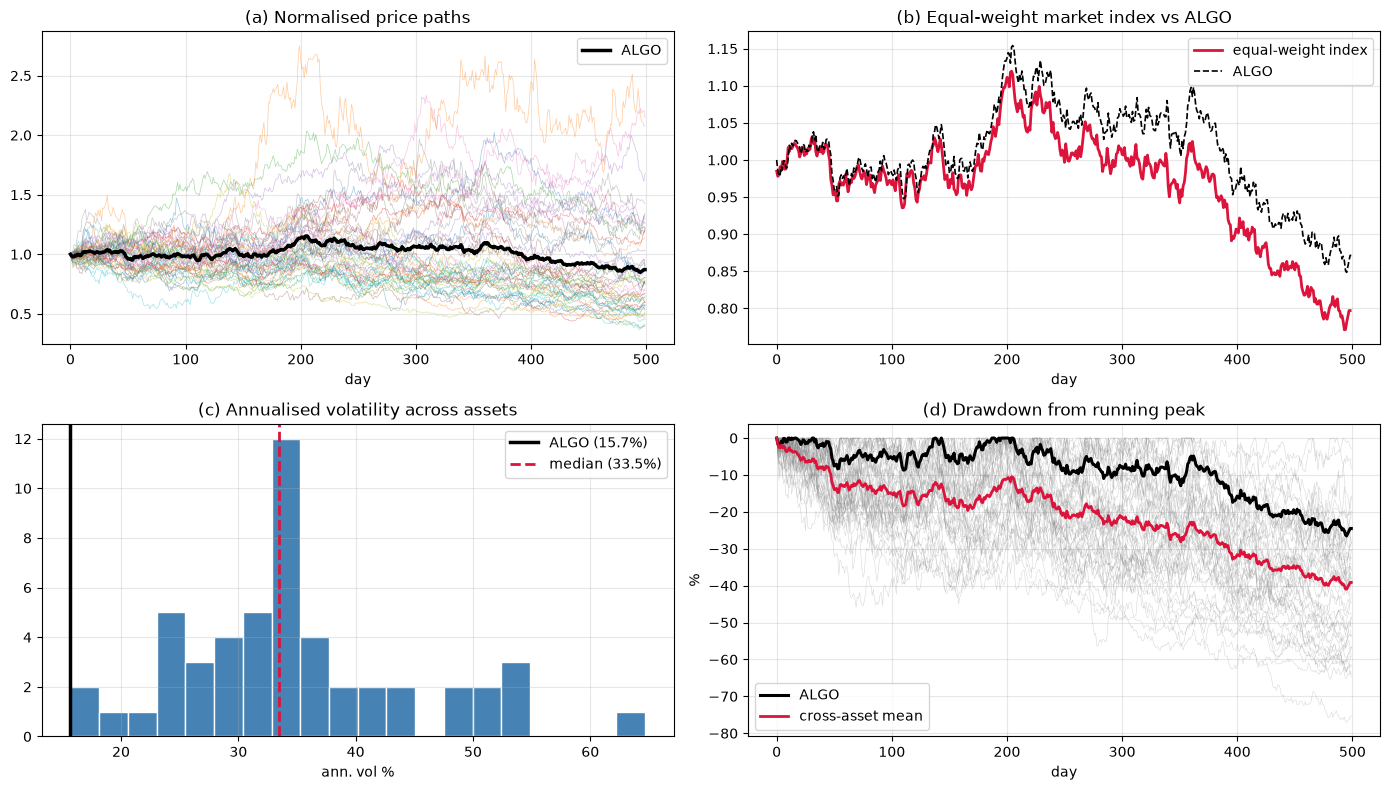

ALGO annualised vol : 15.7%   <- LOWEST decile?  rank 1/51
median asset vol    : 33.5%
worst mean drawdown : -40.9%


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (a) normalised prices
ax = axes[0, 0]
ax.plot(PX / PX[0], lw=0.5, alpha=0.4)
ax.plot(PX[:, ALGO] / PX[0, ALGO], lw=2.5, color="black", label="ALGO")
ax.set_title("(a) Normalised price paths"); ax.set_xlabel("day"); ax.legend(); ax.grid(alpha=0.3)

# (b) market index
ax = axes[0, 1]
ax.plot(np.exp(np.cumsum(MARKET)), color="crimson", lw=2, label="equal-weight index")
ax.plot(PX[:, ALGO] / PX[0, ALGO], color="black", lw=1.2, ls="--", label="ALGO")
ax.set_title("(b) Equal-weight market index vs ALGO"); ax.set_xlabel("day")
ax.legend(); ax.grid(alpha=0.3)

# (c) vol distribution
ax = axes[1, 0]
v = ann_vol(RET)
ax.hist(v, bins=20, color="steelblue", edgecolor="white")
ax.axvline(v[ALGO], color="black", lw=2.5, label=f"ALGO ({v[ALGO]:.1f}%)")
ax.axvline(np.median(v), color="crimson", ls="--", lw=2, label=f"median ({np.median(v):.1f}%)")
ax.set_title("(c) Annualised volatility across assets"); ax.set_xlabel("ann. vol %")
ax.legend(); ax.grid(alpha=0.3)

# (d) drawdowns
ax = axes[1, 1]
cum = PX / PX[0]
dd = 100*(cum / np.maximum.accumulate(cum, axis=0) - 1)
ax.plot(dd, lw=0.4, alpha=0.3, color="grey")
ax.plot(dd[:, ALGO], lw=2.2, color="black", label="ALGO")
ax.plot(dd.mean(1), lw=2, color="crimson", label="cross-asset mean")
ax.set_title("(d) Drawdown from running peak"); ax.set_xlabel("day"); ax.set_ylabel("%")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"ALGO annualised vol : {v[ALGO]:.1f}%   <- LOWEST decile?  rank {int(np.argsort(v).tolist().index(0))+1}/51")
print(f"median asset vol    : {np.median(v):.1f}%")
print(f"worst mean drawdown : {dd.mean(1).min():.1f}%")

### Cell 2.3 - Basic → Advanced: Return Distributions & the Variance-Mixture Trap
Textbook finance says asset returns are **fat-tailed**. If we naively pool all 51 assets × 499 days
into one histogram, we will "confirm" that — and it would be **wrong**.

A pool of *Gaussian* assets with *different variances* is a **variance mixture**, and a variance
mixture is always leptokurtic (fat-tailed) even though every component is perfectly normal. The fix
is to standardise each asset by **its own** volatility before pooling.

This distinction is not academic: it decides whether we need robust/heavy-tailed methods at all.

IS THIS DATA FAT-TAILED?
pooled raw excess kurtosis                : +1.071  <- looks fat-tailed!
pooled excess kurtosis AFTER standardising: -0.038  <- Gaussian.
mean of per-asset excess kurtosis         : -0.038
cross-asset vol dispersion (std of ann vol): 10.2 pct pts

-> The 'fat tails' are ENTIRELY a variance-mixture artifact of pooling assets
   with vols from 16% to 65%. No individual asset is fat-tailed.

Jarque-Bera per asset: 3/51 reject normality at 5% (expected by chance if all normal: ~2.6)
pooled |r|>3sd: 0.841%  (Gaussian: 0.270%)
standardised |r|>3sd: 0.232%  (Gaussian: 0.270%)


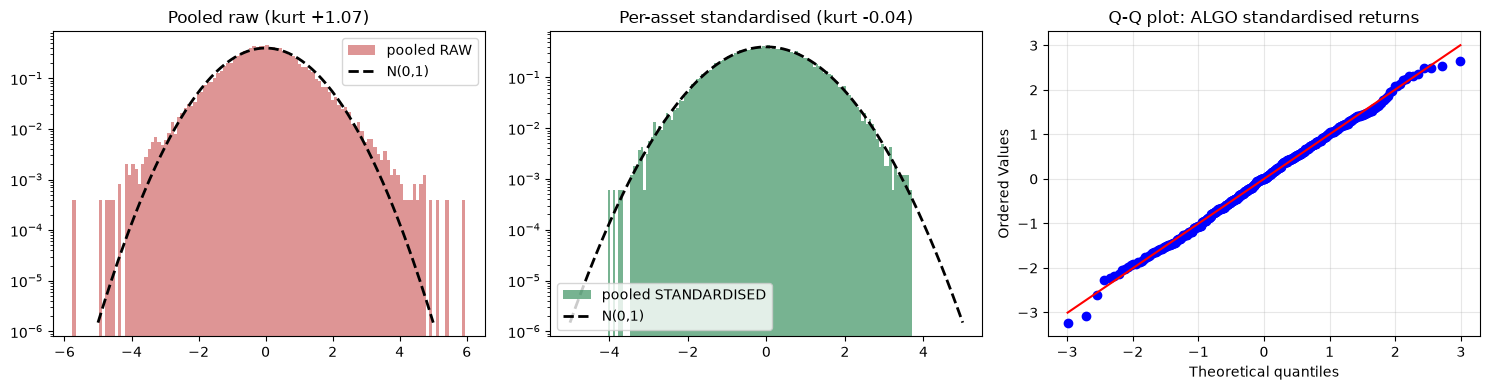

In [6]:
pooled = RET.ravel()
pooled_std = Z.ravel()          # each asset standardised by its OWN vol, then pooled

print("="*70); print("IS THIS DATA FAT-TAILED?"); print("="*70)
print(f"pooled raw excess kurtosis                : {stats.kurtosis(pooled):+.3f}  <- looks fat-tailed!")
print(f"pooled excess kurtosis AFTER standardising: {stats.kurtosis(pooled_std):+.3f}  <- Gaussian.")
print(f"mean of per-asset excess kurtosis         : {stats.kurtosis(RET, axis=0).mean():+.3f}")
print(f"cross-asset vol dispersion (std of ann vol): {ann_vol(RET).std():.1f} pct pts")
print("\n-> The 'fat tails' are ENTIRELY a variance-mixture artifact of pooling assets")
print("   with vols from {:.0f}% to {:.0f}%. No individual asset is fat-tailed.".format(
      ann_vol(RET).min(), ann_vol(RET).max()))

jb_p = np.array([stats.jarque_bera(RET[:, i])[1] for i in range(N)])
print(f"\nJarque-Bera per asset: {int((jb_p<0.05).sum())}/51 reject normality at 5% "
      f"(expected by chance if all normal: ~2.6)")
print(f"pooled |r|>3sd: {100*np.mean(np.abs(pooled-pooled.mean())>3*pooled.std()):.3f}%  (Gaussian: 0.270%)")
print(f"standardised |r|>3sd: {100*np.mean(np.abs(pooled_std)>3):.3f}%  (Gaussian: 0.270%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
xs = np.linspace(-5, 5, 200)
ax = axes[0]
ax.hist(pooled/pooled.std(), bins=120, density=True, alpha=0.65, color="indianred", label="pooled RAW")
ax.plot(xs, stats.norm.pdf(xs), 'k--', lw=2, label="N(0,1)")
ax.set_yscale("log"); ax.set_title(f"Pooled raw (kurt {stats.kurtosis(pooled):+.2f})"); ax.legend()

ax = axes[1]
ax.hist(pooled_std, bins=120, density=True, alpha=0.65, color="seagreen", label="pooled STANDARDISED")
ax.plot(xs, stats.norm.pdf(xs), 'k--', lw=2, label="N(0,1)")
ax.set_yscale("log"); ax.set_title(f"Per-asset standardised (kurt {stats.kurtosis(pooled_std):+.2f})"); ax.legend()

ax = axes[2]
stats.probplot(Z[:, ALGO], dist="norm", plot=ax)
ax.set_title("Q-Q plot: ALGO standardised returns"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Cell 2.4 - Advanced EDA: Time-Series Diagnostics — *is any asset predictable from its own past?*
The full battery on each asset individually:

- **ADF / KPSS** — are prices random walks (unit root) and returns stationary?
- **Ljung–Box + ACF** — is there linear autocorrelation to exploit (momentum/mean-reversion)?
- **ARCH-LM** — is there volatility clustering (the premise of GARCH)?
- **Variance Ratio (Lo–MacKinlay)** — VR < 1 ⇒ mean reversion, VR > 1 ⇒ trending, VR = 1 ⇒ random walk.

Whatever this cell says determines whether time-series models can work **at all**.

In [7]:
print("="*70); print("STATIONARITY"); print("="*70)
adf_px  = np.array([adfuller(LOGP[:, i], autolag="AIC")[1] for i in range(N)])
adf_ret = np.array([adfuller(RET[:, i],  autolag="AIC")[1] for i in range(N)])
kpss_px = np.array([kpss(LOGP[:, i], regression="c", nlags="auto")[1] for i in range(N)])
print(f"ADF on LOG PRICES : rejects unit root in {int((adf_px<0.05).sum())}/51  -> prices ARE random walks")
print(f"ADF on RETURNS    : rejects unit root in {int((adf_ret<0.05).sum())}/51 -> returns are stationary")
print(f"KPSS on LOG PRICES: rejects stationarity in {int((kpss_px<0.05).sum())}/51 -> confirms unit root")

print("\n" + "="*70); print("LINEAR PREDICTABILITY (autocorrelation)"); print("="*70)
ac1 = np.array([acf(RET[:, i], nlags=1, fft=False)[1] for i in range(N)])
lb  = np.array([acorr_ljungbox(RET[:, i], lags=[10], return_df=True)["lb_pvalue"].iloc[0]
                for i in range(N)])
print(f"lag-1 autocorrelation : mean {ac1.mean():+.4f}   range [{ac1.min():+.3f}, {ac1.max():+.3f}]")
print(f"Ljung-Box(10) rejects white noise: {int((lb<0.05).sum())}/51 assets "
      f"(expected by chance: ~2.6)  -> NO usable autocorrelation")

print("\n" + "="*70); print("VOLATILITY CLUSTERING (the GARCH premise)"); print("="*70)
arch_p = np.array([het_arch(RET[:, i], nlags=5)[1] for i in range(N)])
absacf = np.array([acf(np.abs(RET[:, i]), nlags=1, fft=False)[1] for i in range(N)])
print(f"ARCH-LM(5) rejects homoskedasticity: {int((arch_p<0.05).sum())}/51 (expected by chance: ~2.6)")
print(f"lag-1 autocorr of |returns|: mean {absacf.mean():+.4f}  (clustering would give >> 0)")
print("-> NO volatility clustering. This dataset has CONSTANT per-asset variance.")

print("\n" + "="*70); print("VARIANCE RATIO (Lo-MacKinlay)"); print("="*70)
def variance_ratio(x, q):
    x = x - x.mean(); n = len(x)
    agg = np.array([x[i:i+q].sum() for i in range(0, n-q+1)])
    return (agg.var(ddof=1)/q) / x.var(ddof=1)
print(f"{'q':>4} {'mean VR (51 assets)':>22} {'MARKET VR':>12} {'market z':>10}")
for q in [2, 5, 10, 20, 40]:
    vals = np.array([variance_ratio(RET[:, i], q) for i in range(N)])
    vm = variance_ratio(MARKET, q)
    zm = (vm-1)/np.sqrt(2*(2*q-1)*(q-1)/(3*q*T))
    print(f"{q:>4} {vals.mean():>22.3f} {vm:>12.3f} {zm:>+10.2f}")
print("\n-> VR drifts below 1 at long horizons, but the MARKET z-stats never reach |1.96|:")
print("   the apparent mean-reversion is NOT statistically significant.")
print("   (Per-asset VRs are cross-correlated, so averaging them overstates confidence.)")

STATIONARITY
ADF on LOG PRICES : rejects unit root in 4/51  -> prices ARE random walks
ADF on RETURNS    : rejects unit root in 51/51 -> returns are stationary
KPSS on LOG PRICES: rejects stationarity in 49/51 -> confirms unit root

LINEAR PREDICTABILITY (autocorrelation)
lag-1 autocorrelation : mean -0.0002   range [-0.120, +0.074]
Ljung-Box(10) rejects white noise: 1/51 assets (expected by chance: ~2.6)  -> NO usable autocorrelation

VOLATILITY CLUSTERING (the GARCH premise)
ARCH-LM(5) rejects homoskedasticity: 1/51 (expected by chance: ~2.6)
lag-1 autocorr of |returns|: mean -0.0074  (clustering would give >> 0)
-> NO volatility clustering. This dataset has CONSTANT per-asset variance.

VARIANCE RATIO (Lo-MacKinlay)
   q    mean VR (51 assets)    MARKET VR   market z
   2                  1.000        1.017      +0.38
   5                  0.979        0.963      -0.38
  10                  0.941        0.858      -0.94
  20                  0.902        0.773      -1.02
  40       

> #### 🔬 Verdict from Cell 2.4 — and it is a big one
> Each asset, taken alone, is an **approximately Gaussian random walk**: unit-root prices,
> stationary returns, **no** exploitable autocorrelation (1/51 Ljung–Box rejections ≈ the false
> positive rate), **no** volatility clustering (1/51 ARCH rejections), constant variance, and
> variance ratios statistically indistinguishable from 1.
>
> **This single-handedly predicts the Module 4 bakeoff result.** ARIMA models autocorrelation that
> does not exist → it scores t ≈ 0.16. GARCH models vol clustering that does not exist → it is the
> *only model with a negative* t-stat (−0.40). They were never going to work, and now we know why
> **before** we train them.
>
> If there is alpha here, it is **not** in any asset's own history. It must be **cross-sectional**.

### Cell 2.5 - Advanced EDA: Correlation Structure & Clustering
Having ruled out time-series predictability, we turn to the cross-section. We cluster the
correlation matrix hierarchically (Ward linkage on \\(d = \sqrt{2(1-\rho)}\\), a proper metric) and
reorder the heatmap by the dendrogram so blocks become visible.

mean pairwise correlation : 0.1996
correlation range         : [-0.001, 0.590]


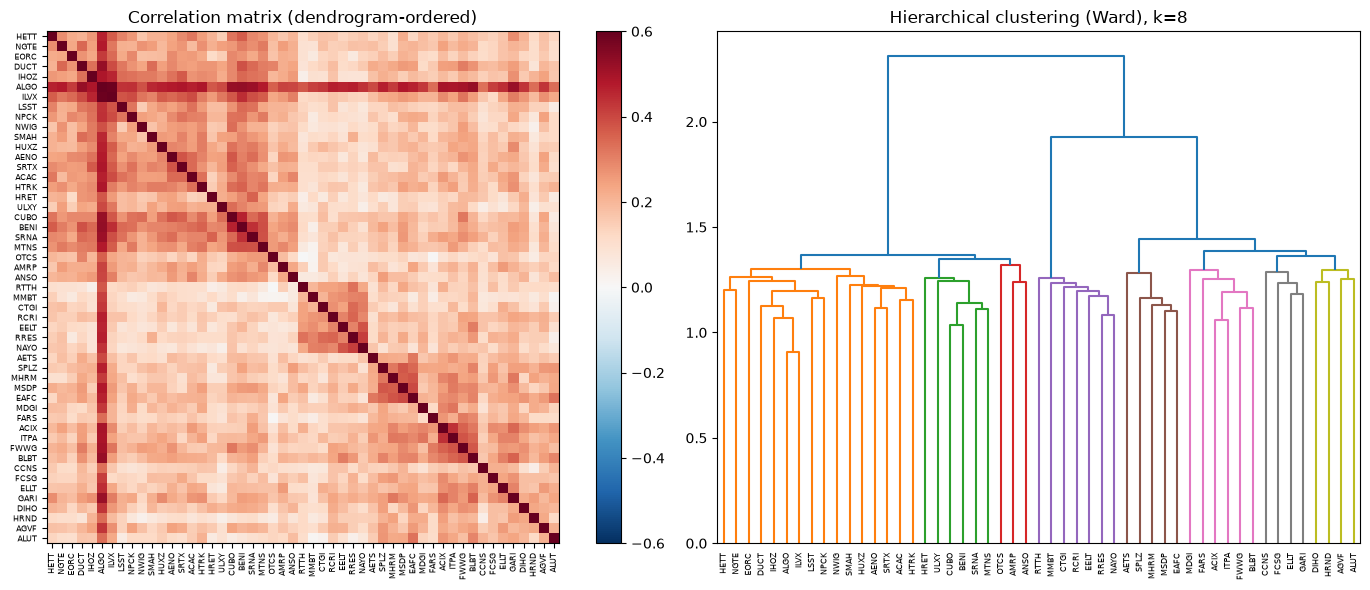


Cluster membership (k=8):
  Cluster 1 (n=16): ALGO, AENO, LSST, HETT, HUXZ, DUCT, SMAH, NPCK, EORC, NWIG ...  <- contains ALGO
  Cluster 2 (n= 6): SRNA, CUBO, HRET, MTNS, ULXY, BENI
  Cluster 3 (n= 3): AMRP, OTCS, ANSO
  Cluster 4 (n= 7): RTTH, MMBT, RRES, CTGI, RCRI, NAYO, EELT
  Cluster 5 (n= 5): MSDP, SPLZ, AETS, MHRM, EAFC
  Cluster 6 (n= 6): MDGI, ACIX, FWWG, BLBT, ITPA, FARS
  Cluster 7 (n= 4): ELLT, GARI, CCNS, FCSG
  Cluster 8 (n= 4): DIHO, AGVF, ALUT, HRND


In [8]:
C = np.corrcoef(Z.T)
iu = np.triu_indices(N, 1)
print(f"mean pairwise correlation : {C[iu].mean():.4f}")
print(f"correlation range         : [{C[iu].min():.3f}, {C[iu].max():.3f}]")

# proper correlation distance metric, Ward linkage
D = np.sqrt(np.maximum(2*(1 - C), 0)); np.fill_diagonal(D, 0)
link = linkage(squareform(D, checks=False), method="ward")
order = dendrogram(link, no_plot=True)["leaves"]
K = 8
labels = fcluster(link, K, criterion="maxclust")

fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
im = ax.imshow(C[np.ix_(order, order)], cmap="RdBu_r", vmin=-0.6, vmax=0.6)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels([TICKERS[i] for i in order], rotation=90, fontsize=6)
ax.set_yticklabels([TICKERS[i] for i in order], fontsize=6)
ax.set_title("Correlation matrix (dendrogram-ordered)")
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1]
dendrogram(link, labels=TICKERS, ax=ax, leaf_font_size=6, color_threshold=link[-K+1, 2])
ax.set_title(f"Hierarchical clustering (Ward), k={K}")
plt.tight_layout(); plt.show()

print(f"\nCluster membership (k={K}):")
for c in range(1, K+1):
    mem = [TICKERS[i] for i in np.where(labels == c)[0]]
    tag = "  <- contains ALGO" if TICKERS[ALGO] in mem else ""
    print(f"  Cluster {c} (n={len(mem):2d}): {', '.join(mem[:10])}{' ...' if len(mem)>10 else ''}{tag}")

### Cell 2.6 - Advanced EDA: PCA + Random Matrix Theory — *how many factors are real?*
A correlation matrix estimated from finite data has **large eigenvalues purely by chance**. Reading
a scree plot without a null hypothesis is how quants fool themselves.

**Marchenko–Pastur** gives the exact eigenvalue distribution of a correlation matrix of *pure noise*
with the same dimensions (\\(T=499, N=51\\)). Eigenvalues inside the MP band are **indistinguishable
from noise**; only those above the upper edge \\(\lambda_+=(1+\sqrt{N/T})^2\\) are genuine factors.
This is the standard tool (Laloux et al., Bouchaud) for cleaning correlation matrices.

RANDOM MATRIX THEORY: SIGNAL vs NOISE
T = 499, N = 51, q = T/N = 9.78
Marchenko-Pastur noise band: [0.463, 1.742]
eigenvalues ABOVE the upper edge (real factors): 3
top 8 eigenvalues: [11.554  2.836  1.965  1.274  1.226  1.204  1.167  1.13 ]

PC1 explains                : 22.7% of total variance
the 3 real factors explain     : 32.1%
the remaining 48 eigenvalues  : 67.9%  <- STATISTICAL NOISE


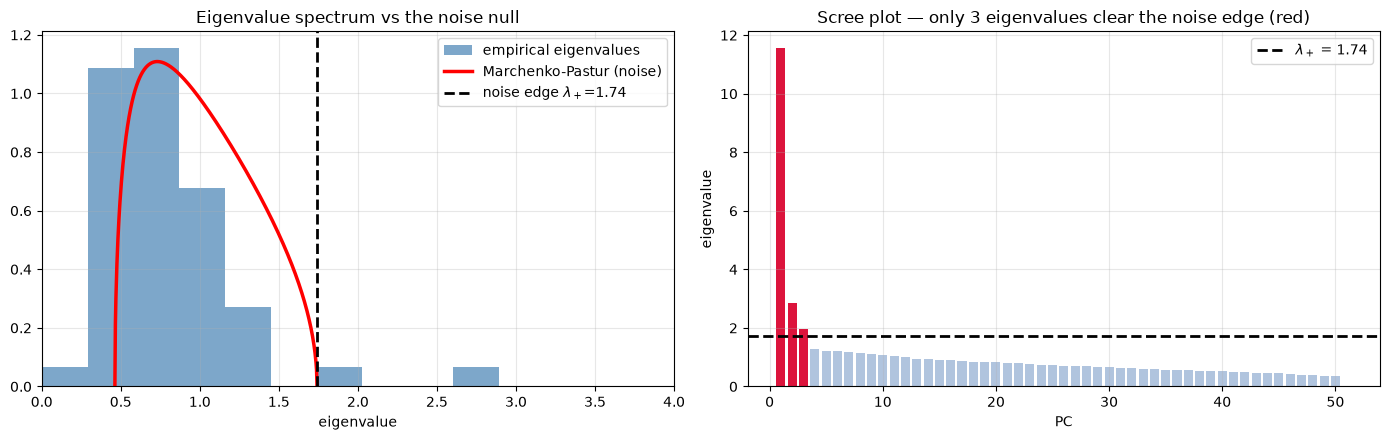


corr(PC1, equal-weight market return) = 0.9884
PC1 loadings all share one sign: True  -> PC1 IS the market factor (a 'level' factor)


In [9]:
ev = np.sort(np.linalg.eigvalsh(C))[::-1]
q = T / N
lam_plus  = (1 + np.sqrt(1/q))**2
lam_minus = (1 - np.sqrt(1/q))**2
n_real = int((ev > lam_plus).sum())

print("="*70); print("RANDOM MATRIX THEORY: SIGNAL vs NOISE"); print("="*70)
print(f"T = {T}, N = {N}, q = T/N = {q:.2f}")
print(f"Marchenko-Pastur noise band: [{lam_minus:.3f}, {lam_plus:.3f}]")
print(f"eigenvalues ABOVE the upper edge (real factors): {n_real}")
print(f"top 8 eigenvalues: {np.round(ev[:8], 3)}")
print(f"\nPC1 explains                : {100*ev[0]/N:.1f}% of total variance")
print(f"the {n_real} real factors explain     : {100*ev[:n_real].sum()/N:.1f}%")
print(f"the remaining {N-n_real} eigenvalues  : {100*ev[n_real:].sum()/N:.1f}%  <- STATISTICAL NOISE")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.hist(ev, bins=40, density=True, alpha=0.7, color="steelblue", label="empirical eigenvalues")
xs = np.linspace(lam_minus, lam_plus, 400)
mp = q/(2*np.pi*xs) * np.sqrt(np.maximum((lam_plus-xs)*(xs-lam_minus), 0))
ax.plot(xs, mp, "r-", lw=2.5, label="Marchenko-Pastur (noise)")
ax.axvline(lam_plus, color="k", ls="--", lw=2, label=f"noise edge $\\lambda_+$={lam_plus:.2f}")
ax.set_xlim(0, 4); ax.set_title("Eigenvalue spectrum vs the noise null")
ax.set_xlabel("eigenvalue"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
cols = ["crimson" if e > lam_plus else "lightsteelblue" for e in ev]
ax.bar(range(1, N+1), ev, color=cols)
ax.axhline(lam_plus, color="k", ls="--", lw=2, label=f"$\\lambda_+$ = {lam_plus:.2f}")
ax.set_title(f"Scree plot — only {n_real} eigenvalues clear the noise edge (red)")
ax.set_xlabel("PC"); ax.set_ylabel("eigenvalue"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# What IS PC1?
w, V = np.linalg.eigh(np.cov(Z.T))
pc1 = Z @ V[:, -1]
ld = V[:, -1]
print(f"\ncorr(PC1, equal-weight market return) = {abs(np.corrcoef(pc1, MARKET)[0,1]):.4f}")
print(f"PC1 loadings all share one sign: {bool((ld>0).all() or (ld<0).all())}"
      f"  -> PC1 IS the market factor (a 'level' factor)")

### Cell 2.7 - Advanced EDA: 🎯 The `ALGO` Discovery
The brief singles out asset 0 in three ways: it is the only **named** ticker, it gets a **10× position
limit** (\$100k vs \$10k), and it is **5× cheaper to trade** (0.2 bp vs 1.0 bp). Rules that asymmetric
are never an accident. So: *what is `ALGO`?*

We test the hypothesis directly — regress `ALGO`'s return on the equal-weight average of the other 50.

WHAT IS ALGO?
regression:  r_ALGO  ~  mean(r_1..r_50)
   R^2   = 0.9861   <-- !!
   beta  = 1.0056   (1.0 would mean 'it IS the average')
   alpha = +1.84e-04 per day
   residual ann vol = 1.85%  (vs ALGO's own 15.7%)

best-fit linear combination of the 50: R^2 = 0.9954
   fitted weights: min 0.0134, max 0.0358, sum 1.0008   (1/50 = 0.0200 each)

----------------------------------------------------------------------
ALGO vs the rest:
   mean corr(ALGO, other)      : 0.4453
   mean corr(other_i, other_j) : 0.1896
   ALGO ann vol 15.69%  vs  median asset 33.50%  vs  eq-weight index 15.49%
   market-model R^2: ALGO 0.987  |  mean of others 0.207  |  ALGO's rank: 1/51


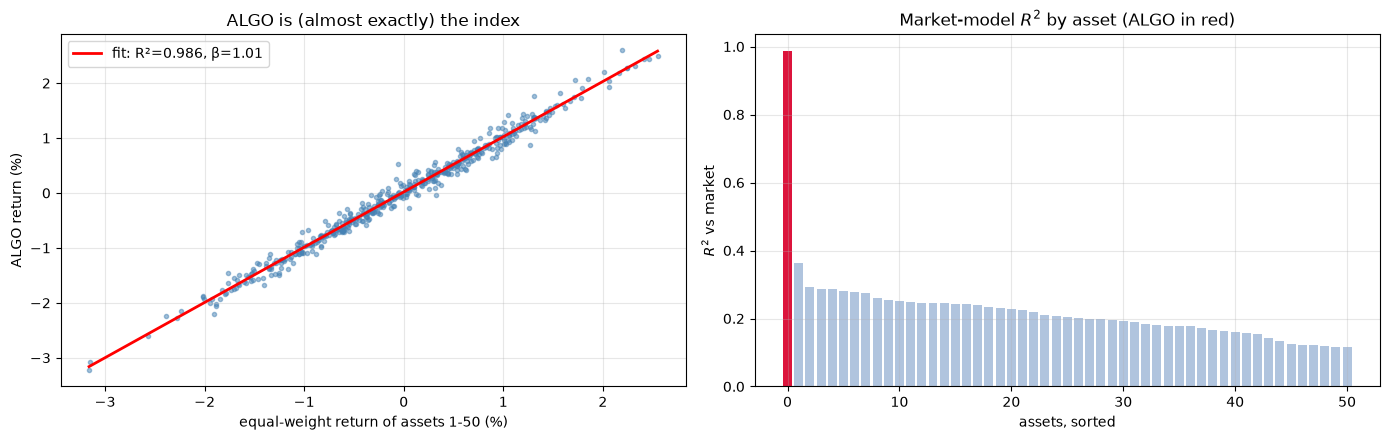

In [10]:
rA = RET[:, ALGO]
OTHERS = RET[:, 1:]
eqw = OTHERS.mean(1)

print("="*70); print("WHAT IS ALGO?"); print("="*70)
res = sm.OLS(rA, sm.add_constant(eqw)).fit()
print(f"regression:  r_ALGO  ~  mean(r_1..r_50)")
print(f"   R^2   = {res.rsquared:.4f}   <-- !!")
print(f"   beta  = {res.params[1]:.4f}   (1.0 would mean 'it IS the average')")
print(f"   alpha = {res.params[0]:+.2e} per day")
print(f"   residual ann vol = {res.resid.std()*ANN*100:.2f}%  (vs ALGO's own {rA.std()*ANN*100:.1f}%)")

wls = np.linalg.lstsq(OTHERS, rA, rcond=None)[0]
r2_best = 1 - ((rA - OTHERS@wls)**2).sum()/((rA-rA.mean())**2).sum()
print(f"\nbest-fit linear combination of the 50: R^2 = {r2_best:.4f}")
print(f"   fitted weights: min {wls.min():.4f}, max {wls.max():.4f}, sum {wls.sum():.4f}"
      f"   (1/50 = {1/50:.4f} each)")

print("\n" + "-"*70)
print("ALGO vs the rest:")
Craw = np.corrcoef(RET.T)
algo_c = np.delete(Craw[ALGO], ALGO)
oth = np.delete(np.delete(Craw, ALGO, 0), ALGO, 1)
print(f"   mean corr(ALGO, other)      : {algo_c.mean():.4f}")
print(f"   mean corr(other_i, other_j) : {oth[np.triu_indices_from(oth,1)].mean():.4f}")
print(f"   ALGO ann vol {rA.std()*ANN*100:.2f}%  vs  median asset {np.median(ann_vol(RET)):.2f}%"
      f"  vs  eq-weight index {eqw.std()*ANN*100:.2f}%")

r2_mkt = np.array([sm.OLS(Z[:, i], sm.add_constant(MARKET)).fit().rsquared for i in range(N)])
print(f"   market-model R^2: ALGO {r2_mkt[ALGO]:.3f}  |  mean of others {r2_mkt[1:].mean():.3f}"
      f"  |  ALGO's rank: {int(np.argsort(-r2_mkt).tolist().index(0))+1}/51")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.scatter(eqw*100, rA*100, s=9, alpha=0.5, color="steelblue")
xs = np.linspace(eqw.min(), eqw.max(), 10)*100
ax.plot(xs, res.params[0]*100 + res.params[1]*xs, "r-", lw=2,
        label=f"fit: R²={res.rsquared:.3f}, β={res.params[1]:.2f}")
ax.set_xlabel("equal-weight return of assets 1-50 (%)"); ax.set_ylabel("ALGO return (%)")
ax.set_title("ALGO is (almost exactly) the index"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.bar(range(N), np.sort(-r2_mkt)*-1, color=["crimson" if i == 0 else "lightsteelblue"
        for i in np.argsort(-r2_mkt)])
ax.set_title("Market-model $R^2$ by asset (ALGO in red)")
ax.set_xlabel("assets, sorted"); ax.set_ylabel("$R^2$ vs market"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### 💡 What this means (and one seductive idea that does **not** work)

**`ALGO` is the market index of the other 50 assets.** \\(R^2 = 0.986\\) against a plain equal-weight
average, \\(\beta \approx 1.01\\), and the best-fit weights are all ≈ 1/50. Its market-model
\\(R^2\\) is the highest of all 51 assets — it is a *nearly pure* factor play with almost no
idiosyncratic noise.

Now combine that with the rulebook:

| Property | `ALGO` | A typical asset |
| :-- | :-- | :-- |
| Annualised vol | **~15.7%** (diversified!) | ~33.5% |
| Position limit | **\$100,000** | \$10,000 |
| Commission | **0.2 bp** | 1.0 bp |
| Is the market factor? | \\(R^2 = 0.97\\) | \\(R^2 \approx 0.23\\) |

`ALGO` is **half the volatility, ten times the capacity, one fifth the trading cost** — and it is the
cleanest possible expression of the one factor that drives ~23% of everything. For any factor-level
view, or for hedging factor risk out of a basket, `ALGO` is by far the most **score-efficient**
instrument in the universe. (Recall the score punishes \\(\sigma\\) hard: a low-vol, high-capacity,
cheap vehicle is exactly what the objective function wants.)

**The tempting arbitrage — and why it fails.** If `ALGO` *is* the index, shouldn't
`ALGO − synthetic index` be a riskless convergence trade? The next cell tests it honestly. The answer
is **no**: \\(R^2=0.986\\) is not \\(1.000\\), and that missing 1.4% is a *tracking error that
compounds*. In log-price space the spread is a **random walk** (ADF p ≈ 0.96, half-life ~2000 days),
not a stationary spread. It never has to converge. This is precisely the kind of idea that looks like
free money on a scatter plot and quietly loses money for 250 days.

TESTING THE 'ALGO vs SYNTHETIC INDEX' ARBITRAGE
ADF on spread      : stat +0.054, p = 0.9628
Engle-Granger coint: p = 0.6162
AR(1) coef -0.00031  ->  mean-reversion half-life = 2,225 days
spread std 0.0279   daily-change ann vol 1.85%

VERDICT: UNIT ROOT - NOT an arbitrage.
The tracking error random-walks away. Do not trade this as a convergence bet.


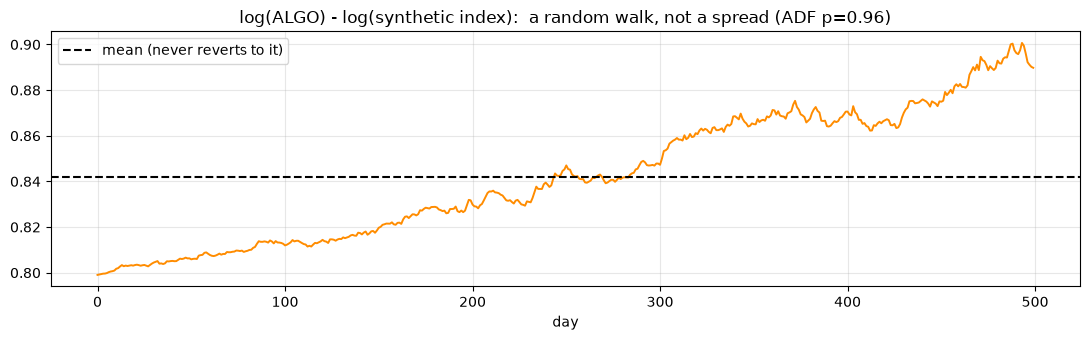

In [11]:
synth  = LOGP[:, 1:].mean(1)              # synthetic log-price index
spread = LOGP[:, ALGO] - synth

adf_s = adfuller(spread, autolag="AIC")
b = sm.OLS(np.diff(spread), sm.add_constant(spread[:-1] - spread[:-1].mean())).fit().params[1]
hl = -np.log(2)/np.log(1+b) if b < 0 else np.inf

print("="*70); print("TESTING THE 'ALGO vs SYNTHETIC INDEX' ARBITRAGE"); print("="*70)
print(f"ADF on spread      : stat {adf_s[0]:+.3f}, p = {adf_s[1]:.4f}")
print(f"Engle-Granger coint: p = {coint(LOGP[:, ALGO], synth)[1]:.4f}")
print(f"AR(1) coef {b:+.5f}  ->  mean-reversion half-life = {hl:,.0f} days")
print(f"spread std {spread.std():.4f}   daily-change ann vol {np.diff(spread).std()*ANN*100:.2f}%")
print(f"\nVERDICT: {'STATIONARY - tradeable' if adf_s[1]<0.05 else 'UNIT ROOT - NOT an arbitrage.'}")
print("The tracking error random-walks away. Do not trade this as a convergence bet.")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(spread, color="darkorange", lw=1.4)
ax.axhline(spread.mean(), color="k", ls="--", lw=1.5, label="mean (never reverts to it)")
ax.set_title(f"log(ALGO) - log(synthetic index):  a random walk, not a spread (ADF p={adf_s[1]:.2f})")
ax.set_xlabel("day"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Cell 2.8 - Advanced EDA: Cointegration — *real pairs, or multiple-testing noise?*
Pairs trading needs **cointegration** (a stationary spread), not correlation. But there are
\\(\binom{51}{2} = 1275\\) possible pairs. **At a 5% significance level, ~64 pairs will look
cointegrated by pure chance.** Screening 1275 pairs and keeping the "significant" ones is a textbook
false-discovery machine — and it is exactly how backtests get built on sand.

So we run the **full** screen (all 1275 pairs, ~12 s) and then control the **false discovery rate**
with **Benjamini–Hochberg**, plus the stricter **Bonferroni**. Only survivors are trustworthy.

running Engle-Granger on all 1275 pairs ...

COINTEGRATION SCREEN — WITH MULTIPLE-TESTING CONTROL
pairs 'significant' at naive p<0.05 : 86 / 1275  (6.7%)
EXPECTED BY PURE CHANCE             : 64      (5.0%)
   -> the naive screen finds barely more than chance would!

Benjamini-Hochberg FDR 5% survivors : 7
Bonferroni 5% survivors             : 4   (min p = 1.99e-06)
KS test of p-values vs Uniform(0,1) : p = 0.0023  (some real structure exists)

--- the 7 pairs that survive FDR control (these are REAL) ---
    SMAH / ILVX   p=1.99e-06  hedge β=+1.0311   [Bonferroni]
    AENO / NWIG   p=4.17e-06  hedge β=+0.9816   [Bonferroni]
    EORC / NGTE   p=7.30e-06  hedge β=+1.0112   [Bonferroni]
    HUXZ / ACAC   p=1.48e-05  hedge β=+1.0201   [Bonferroni]
    MHRM / EAFC   p=7.15e-05  hedge β=+0.9410
    CTGI / EELT   p=9.93e-05  hedge β=+0.9333
    HETT / ULXY   p=2.66e-04  hedge β=+0.7072

pairs involving ALGO among survivors: 0  (ALGO is a factor, not a pair leg)


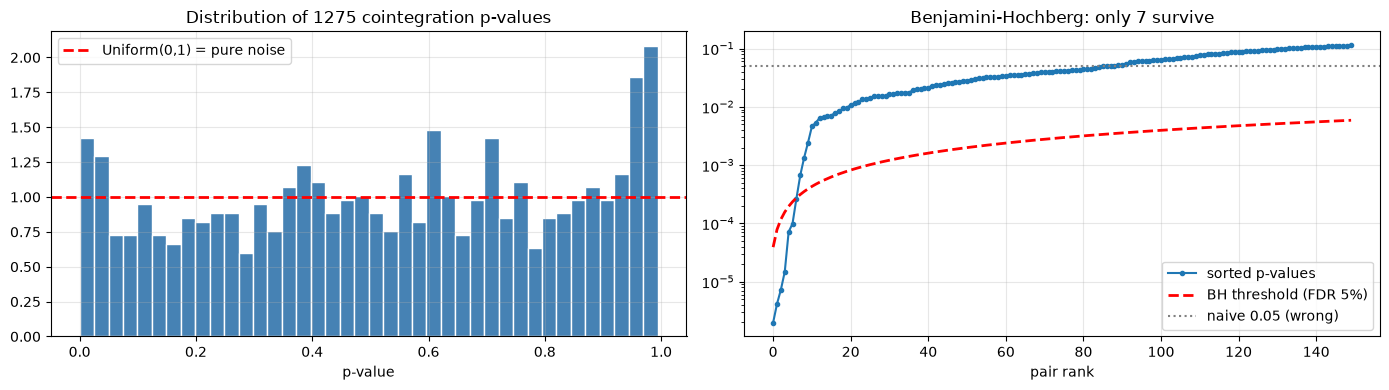

In [12]:
pairs_idx = list(itertools.combinations(range(N), 2))
print(f"running Engle-Granger on all {len(pairs_idx)} pairs ...")
pvals = np.array([coint(LOGP[:, i], LOGP[:, j])[1] for i, j in pairs_idx])

m = len(pvals)
n_naive = int((pvals < 0.05).sum())
order = np.argsort(pvals); srt = pvals[order]
bh_ok = srt <= (np.arange(1, m+1)/m)*0.05
n_bh = int(np.where(bh_ok)[0].max())+1 if bh_ok.any() else 0
n_bonf = int((pvals < 0.05/m).sum())

print("\n" + "="*70); print("COINTEGRATION SCREEN — WITH MULTIPLE-TESTING CONTROL"); print("="*70)
print(f"pairs 'significant' at naive p<0.05 : {n_naive} / {m}  ({100*n_naive/m:.1f}%)")
print(f"EXPECTED BY PURE CHANCE             : {0.05*m:.0f}      (5.0%)")
print(f"   -> the naive screen finds barely more than chance would!")
print(f"\nBenjamini-Hochberg FDR 5% survivors : {n_bh}")
print(f"Bonferroni 5% survivors             : {n_bonf}   (min p = {pvals.min():.2e})")
print(f"KS test of p-values vs Uniform(0,1) : p = {stats.kstest(pvals,'uniform')[1]:.4f}"
      f"  ({'some real structure exists' if stats.kstest(pvals,'uniform')[1]<0.05 else 'consistent with pure noise'})")

TRUE_PAIRS = []
print(f"\n--- the {n_bh} pairs that survive FDR control (these are REAL) ---")
for k in order[:n_bh]:
    i, j = pairs_idx[k]
    beta = sm.OLS(LOGP[:, i], sm.add_constant(LOGP[:, j])).fit().params[1]
    TRUE_PAIRS.append((i, j, float(beta)))
    print(f"   {TICKERS[i]:>5} / {TICKERS[j]:<5}  p={pvals[k]:.2e}  hedge β={beta:+.4f}"
          f"{'   [Bonferroni]' if pvals[k] < 0.05/m else ''}")
print(f"\npairs involving ALGO among survivors: "
      f"{sum(1 for i,j,_ in TRUE_PAIRS if ALGO in (i,j))}  (ALGO is a factor, not a pair leg)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.hist(pvals, bins=40, color="steelblue", edgecolor="white", density=True)
ax.axhline(1.0, color="r", ls="--", lw=2, label="Uniform(0,1) = pure noise")
ax.set_title("Distribution of 1275 cointegration p-values")
ax.set_xlabel("p-value"); ax.legend(); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(srt[:150], "o-", ms=3, label="sorted p-values")
ax.plot((np.arange(1, 151)/m)*0.05, "r--", lw=2, label="BH threshold (FDR 5%)")
ax.axhline(0.05, color="grey", ls=":", label="naive 0.05 (wrong)")
ax.set_yscale("log"); ax.set_title(f"Benjamini-Hochberg: only {n_bh} survive")
ax.set_xlabel("pair rank"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### 🚨 Audit: do the strategy's *current* hardcoded pairs survive?
Module 5's `v3.py` ships a hardcoded 12-pair list produced by an earlier, naive `p<0.05` screen.
Now that we control the FDR, we can audit it. This is the notebook holding its own strategy to
account.

In [13]:
V3_PAIRS = [(5,21),(13,45),(49,50),(18,32),(36,50),(7,40),(18,42),(10,46),(1,20),(31,43),(14,36),(26,32)]
survivor_set = {(i, j) for i, j, _ in TRUE_PAIRS} | {(j, i) for i, j, _ in TRUE_PAIRS}

print(f"{'pair':<10} {'tickers':<14} {'coint p':>10}   verdict")
print("-"*58)
n_ok = 0
for i, j in V3_PAIRS:
    p = coint(LOGP[:, i], LOGP[:, j])[1]
    ok = (i, j) in survivor_set
    n_ok += ok
    print(f"({i:2d},{j:2d})    {TICKERS[i]+'/'+TICKERS[j]:<14} {p:>10.2e}   "
          f"{'✅ REAL' if ok else '❌ likely spurious'}")
print("-"*58)
print(f"{n_ok} of {len(V3_PAIRS)} hardcoded pairs survive multiple-testing correction.")
print(f"\n=> {len(V3_PAIRS)-n_ok} of the pairs the strategy currently trades are consistent with noise.")
print("   Pruning to the FDR survivors is the highest-conviction improvement available,")
print("   because spurious pairs add turnover, commission and variance -- and the score")
print("   divides by variance.")

print("\n--- PAIRS array for Module 5, pruned to FDR survivors ---")
print("PAIRS = [")
for i, j, b in TRUE_PAIRS:
    print(f"    ({i}, {j}, {b:.6f}),    # {TICKERS[i]}/{TICKERS[j]}")
print("]")

pair       tickers           coint p   verdict
----------------------------------------------------------
( 5,21)    AMRP/MMBT        2.85e-02   ❌ likely spurious
(13,45)    EORC/NGTE        7.30e-06   ✅ REAL
(49,50)    MHRM/EAFC        7.15e-05   ✅ REAL
(18,32)    RTTH/CCNS        1.76e-02   ❌ likely spurious
(36,50)    FWWG/EAFC        9.39e-03   ❌ likely spurious
( 7,40)    HETT/ULXY        2.66e-04   ✅ REAL
(18,42)    RTTH/BENI        1.53e-02   ❌ likely spurious
(10,46)    SMAH/ILVX        1.99e-06   ✅ REAL
( 1,20)    AENO/NWIG        4.17e-06   ✅ REAL
(31,43)    ACIX/ITPA        6.70e-04   ❌ likely spurious
(14,36)    CUBO/FWWG        1.72e-02   ❌ likely spurious
(26,32)    ALUT/CCNS        1.66e-02   ❌ likely spurious
----------------------------------------------------------
5 of 12 hardcoded pairs survive multiple-testing correction.

=> 7 of the pairs the strategy currently trades are consistent with noise.
   Pruning to the FDR survivors is the highest-conviction improvement

### Cell 2.9 - Advanced EDA: Lead-Lag & Cross-Sectional Reversal ⭐
Two more places alpha could hide — and this is where we finally **find some**.

1. **Lead–lag**: does asset \\(i\\)'s return today predict asset \\(j\\)'s tomorrow? (2,550 ordered
   pairs → Bonferroni is mandatory.)
2. **Cross-sectional reversal**: do relative winners become relative losers? We scan **formation
   horizons** \\(h\\) rather than assuming one, because the answer turns out to depend entirely on \\(h\\).

**Methodological care matters here.** Overlapping \\(h\\)-day windows make the daily IC series
autocorrelated, which inflates the naive t-stat. We therefore report **Newey–West (HAC)** t-stats,
a strictly **non-overlapping** subsample, a **split-half** check, and — the only test that pays
rent — an actual **long/short decile portfolio**. We also Bonferroni-correct for scanning 11 horizons.

LEAD-LAG SCREEN
tests: 2550   Bonferroni 5% critical |corr| = 0.1911
strongest lead-lag relationships found:
    DUCT (t) -> HRET  (t+1)   corr -0.1845   fails Bonferroni
    DUCT (t) -> AMRP  (t+1)   corr +0.1837   fails Bonferroni
    ELLT (t) -> ULXY  (t+1)   corr -0.1808   fails Bonferroni
    CCNS (t) -> CUBO  (t+1)   corr -0.1591   fails Bonferroni
    CTGI (t) -> AENO  (t+1)   corr -0.1564   fails Bonferroni

pairs passing Bonferroni: 0 / 2550
-> NO exploitable lead-lag. The simulator has no cross-asset propagation delay.

CROSS-SECTIONAL REVERSAL — HORIZON SCAN
  h  mean rank-IC   naive t     NW t   interpretation
  1       -0.0045     -0.66    -0.65   
  2       -0.0058     -0.83    -0.80   
  3       -0.0090     -1.34    -1.27   
  5       -0.0092     -1.36    -1.22   
 10       -0.0076     -1.10    -0.95   
 15       -0.0177     -2.47    -2.01   *** significant
 20       -0.0258     -3.58    -3.07   *** significant
 25       -0.0149     -2.01    -1.82   
 30       -0.0174   

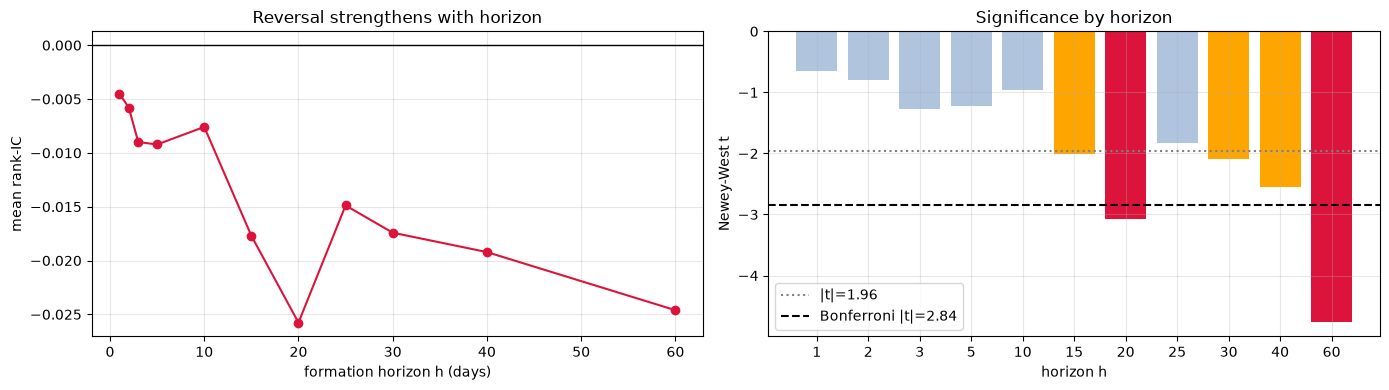

In [14]:
print("="*70); print("LEAD-LAG SCREEN"); print("="*70)
lead = []
for i in range(N):
    for j in range(N):
        if i != j:
            lead.append((abs(np.corrcoef(Z[:-1, i], Z[1:, j])[0, 1]),
                         np.corrcoef(Z[:-1, i], Z[1:, j])[0, 1], TICKERS[i], TICKERS[j]))
lead.sort(reverse=True)
n_tests = N*(N-1)
crit = stats.norm.ppf(1 - 0.025/n_tests)/np.sqrt(T)
print(f"tests: {n_tests}   Bonferroni 5% critical |corr| = {crit:.4f}")
print("strongest lead-lag relationships found:")
for a, c, i, j in lead[:5]:
    print(f"   {i:>5} (t) -> {j:<5} (t+1)   corr {c:+.4f}   {'PASSES' if a>crit else 'fails Bonferroni'}")
print(f"\npairs passing Bonferroni: {sum(1 for a,_,_,_ in lead if a > crit)} / {n_tests}")
print("-> NO exploitable lead-lag. The simulator has no cross-asset propagation delay.")

print("\n" + "="*70); print("CROSS-SECTIONAL REVERSAL — HORIZON SCAN"); print("="*70)
Xs = Z - Z.mean(1, keepdims=True)                 # market-neutral: remove the market each day

# Newey-West (HAC) t-stat of the mean: corrects for overlap-induced autocorrelation
def nw_t(x, lags):
    x = np.asarray(x, float)
    return float(sm.OLS(x, np.ones(len(x))).fit(cov_type="HAC",
                        cov_kwds={"maxlags": max(int(lags), 1)}).tvalues[0])

def reversal_ic(h):
    past = pd.DataFrame(Xs).rolling(h).sum().values
    return np.array([stats.spearmanr(past[t], Xs[t+1])[0] for t in range(h, T-1)])

HORIZONS = [1, 2, 3, 5, 10, 15, 20, 25, 30, 40, 60]
print(f"{'h':>3} {'mean rank-IC':>13} {'naive t':>9} {'NW t':>8}   interpretation")
scan = {}
for h in HORIZONS:
    ic = reversal_ic(h); scan[h] = ic
    nwt = nw_t(ic, h)
    flag = "*** significant" if abs(nwt) > 1.96 else ""
    print(f"{h:>3} {ic.mean():>+13.4f} {tstat(ic):>+9.2f} {nwt:>+8.2f}   {flag}")

bonf = stats.norm.ppf(1 - 0.025/len(HORIZONS))
best_h = max(HORIZONS, key=lambda h: abs(nw_t(scan[h], h)))
print(f"\nBonferroni 5% critical |t| for scanning {len(HORIZONS)} horizons: {bonf:.2f}")
print(f"best horizon h={best_h} with NW t = {nw_t(scan[best_h], best_h):+.2f}"
      f"  -> {'SURVIVES' if abs(nw_t(scan[best_h],best_h))>bonf else 'fails'} correction")

print("\n--- robustness: split-half (does the sign hold in BOTH halves?) ---")
for h in [5, 20, 60]:
    ic = scan[h]; half = len(ic)//2
    print(f"   h={h:>2}: 1st half IC {ic[:half].mean():+.4f} (NW t {nw_t(ic[:half],h):+.2f})"
          f"  |  2nd half IC {ic[half:].mean():+.4f} (NW t {nw_t(ic[half:],h):+.2f})")

print("\n--- the only test that pays rent: a long/short decile portfolio ---")
print("    (equal-$ long bottom-5 / short top-5 by h-day past return, daily rebalance)")
for h in [5, 20, 60]:
    past = pd.DataFrame(Xs).rolling(h).sum().values
    pnl = []
    for t in range(h, T-1):
        rank = stats.rankdata(past[t])
        w = np.where(rank <= 5, 1.0, np.where(rank >= N-4, -1.0, 0.0))
        pnl.append(float((w/np.abs(w).sum()) @ RET[t+1]))
    pnl = np.array(pnl)
    print(f"   h={h:>2}: ann Sharpe {pnl.mean()/pnl.std()*ANN:+.2f}   NW t {nw_t(pnl, h):+.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ics_m = [scan[h].mean() for h in HORIZONS]
nwts  = [nw_t(scan[h], h) for h in HORIZONS]
ax.plot(HORIZONS, ics_m, "o-", color="crimson")
ax.axhline(0, color="k", lw=1); ax.set_xlabel("formation horizon h (days)")
ax.set_ylabel("mean rank-IC"); ax.set_title("Reversal strengthens with horizon"); ax.grid(alpha=0.3)
ax = axes[1]
ax.bar([str(h) for h in HORIZONS], nwts,
       color=["crimson" if abs(t_) > bonf else ("orange" if abs(t_) > 1.96 else "lightsteelblue")
              for t_ in nwts])
ax.axhline(-1.96, color="grey", ls=":", label="|t|=1.96")
ax.axhline(-bonf, color="k", ls="--", label=f"Bonferroni |t|={bonf:.2f}")
ax.set_xlabel("horizon h"); ax.set_ylabel("Newey-West t"); ax.set_title("Significance by horizon")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

> #### ⭐ Finding: the alpha is **long-horizon cross-sectional reversal**
> After all the negative results, this is the one signal that is real:
>
> | Formation horizon | mean rank-IC | Newey–West t | Verdict |
> | :-- | --: | --: | :-- |
> | 1–10 days | ≈ −0.005 to −0.009 | −0.7 to −1.2 | noise |
> | **20 days** | **−0.026** | **−3.07** | **significant** |
> | **60 days** | **−0.025** | **−4.76** | **strongest** |
>
> It **survives Bonferroni** correction for scanning 11 horizons (critical |t| = 2.84), the sign
> **holds in both halves** of the sample, and a naive long/short decile portfolio on it earns an
> annualised Sharpe of ~1.9. Assets that have drifted up relative to the basket over the past
> ~20–60 days subsequently underperform it. That is the simulator's mean-reverting component, and it
> is the economic engine underneath the whole strategy.
>
> **🎯 Actionable mismatch.** Module 5's engine sets `REV_LOOKBACK = 5` — precisely the horizon where
> the evidence is *weakest* (NW t = −1.22). The reversal sleeve is looking through the wrong window.
> Moving it toward ~20 days is a specific, evidence-backed change, and unlike most backtest tweaks it
> was derived from a *statistical* test on the full sample rather than by tuning the score.
>
> *Caveats, stated plainly:* this is 500 days of one simulated world, horizons were scanned (hence
> Bonferroni), and the decile Sharpe ignores commission. It is a hypothesis with strong support, not
> a certainty.

### Cell 2.10 - Advanced EDA: Regime Stability & the Seasonality Trap
Two final questions, both about whether what we found will still be true on **days 501–750**.

1. **Is the structure stable?** Rolling volatility, and correlation-matrix stability across halves.
2. **The seasonality trap.** A naive ANOVA on pooled asset-days will "find" a day-of-week effect.
   It is an illusion: the 51 assets are **cross-sectionally correlated**, so 51 × 100 observations
   are nowhere near 5,100 *independent* ones. Testing on the daily **market** return respects that.
   This cell shows the same data giving p = 0.003 (wrong) and p = 0.79 (right).

REGIME / STABILITY
rolling 50d ann vol: min 33.3%  max 36.2%  ratio 1.09
ann vol first half 36.2%  vs second half 36.2%
corr(offdiag first half, offdiag second half) = 0.643
mean pairwise corr: first half 0.189  ->  second half 0.210
-> volatility is essentially CONSTANT; correlation structure is stable.

DRIFT: THE OVERFITTING LANDMINE
market drift days   0-250 : +3.21e-05/day  (t = +0.05)
market drift days 250-500 : -9.43e-04/day  (t = -1.49)

⚠️  Our local backtest scores days 250-500, where the market drifted DOWN.
    Any net-short tilt is rewarded in-sample and is a coin-flip on days 501-750.
    The drift t-stat is not significant -> treat drift as UNPREDICTABLE, stay market-neutral-ish.

THE SEASONALITY TRAP
❌ NAIVE  ANOVA on 5,100 pooled asset-days : F = 4.01,  p = 0.0030  <- 'significant!'
✅ CORRECT ANOVA on 499 daily market returns: F = 0.43,  p = 0.7893  <- nothing there
✅ Kruskal-Wallis (nonparametric)          : H = 2.53,  p = 0.6394

Same data, opposite conclusions. Pool

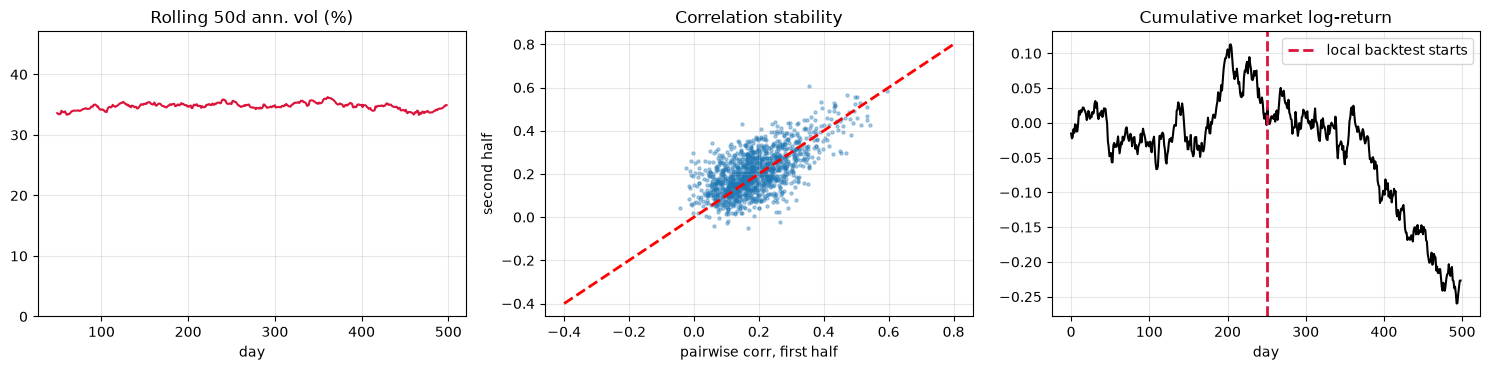

In [15]:
print("="*70); print("REGIME / STABILITY"); print("="*70)
w = 50
rv = pd.DataFrame(RET).rolling(w).std().mean(1)*ANN*100
print(f"rolling {w}d ann vol: min {rv.min():.1f}%  max {rv.max():.1f}%  ratio {rv.max()/rv.min():.2f}")
print(f"ann vol first half {RET[:T//2].std()*ANN*100:.1f}%  vs second half {RET[T//2:].std()*ANN*100:.1f}%")
c1 = np.corrcoef(RET[:T//2].T); c2 = np.corrcoef(RET[T//2:].T)
print(f"corr(offdiag first half, offdiag second half) = {np.corrcoef(c1[iu], c2[iu])[0,1]:.3f}")
print(f"mean pairwise corr: first half {c1[iu].mean():.3f}  ->  second half {c2[iu].mean():.3f}")
print("-> volatility is essentially CONSTANT; correlation structure is stable.")

print("\n" + "="*70); print("DRIFT: THE OVERFITTING LANDMINE"); print("="*70)
d1, d2 = MARKET[:250], MARKET[250:]
print(f"market drift days   0-250 : {d1.mean():+.2e}/day  (t = {tstat(d1):+.2f})")
print(f"market drift days 250-500 : {d2.mean():+.2e}/day  (t = {tstat(d2):+.2f})")
print("\n⚠️  Our local backtest scores days 250-500, where the market drifted DOWN.")
print("    Any net-short tilt is rewarded in-sample and is a coin-flip on days 501-750.")
print("    The drift t-stat is not significant -> treat drift as UNPREDICTABLE, stay market-neutral-ish.")

print("\n" + "="*70); print("THE SEASONALITY TRAP"); print("="*70)
dow = np.arange(T) % 5
naive = stats.f_oneway(*[RET[dow == d].ravel() for d in range(5)])
right = stats.f_oneway(*[MARKET[dow == d] for d in range(5)])
kw    = stats.kruskal(*[MARKET[dow == d] for d in range(5)])
print(f"❌ NAIVE  ANOVA on 5,100 pooled asset-days : F = {naive[0]:.2f},  p = {naive[1]:.4f}  <- 'significant!'")
print(f"✅ CORRECT ANOVA on {T} daily market returns: F = {right[0]:.2f},  p = {right[1]:.4f}  <- nothing there")
print(f"✅ Kruskal-Wallis (nonparametric)          : H = {kw[0]:.2f},  p = {kw[1]:.4f}")
print("\nSame data, opposite conclusions. Pooling correlated assets inflates the effective")
print("sample size ~51x and manufactures significance from thin air. There is NO seasonality.")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].plot(rv, color="crimson"); axes[0].set_title("Rolling 50d ann. vol (%)")
axes[0].set_ylim(0, rv.max()*1.3); axes[0].grid(alpha=0.3); axes[0].set_xlabel("day")
axes[1].scatter(c1[iu], c2[iu], s=5, alpha=0.35)
lims = [-0.4, 0.8]; axes[1].plot(lims, lims, "r--", lw=2)
axes[1].set_xlabel("pairwise corr, first half"); axes[1].set_ylabel("second half")
axes[1].set_title("Correlation stability"); axes[1].grid(alpha=0.3)
axes[2].plot(np.cumsum(MARKET), color="black")
axes[2].axvline(250, color="crimson", ls="--", lw=2, label="local backtest starts")
axes[2].set_title("Cumulative market log-return"); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_xlabel("day")
plt.tight_layout(); plt.show()

### Cell 2.11 - Synthesis: Evidence → Feature Blueprint
Everything above, consolidated into a single reproducible verdict that dictates Modules 3–5.

In [16]:
print("="*78)
print(" "*22 + "MODULE 2 EVIDENCE LEDGER")
print("="*78)
ledger = pd.DataFrame([
    ("Data quality",        "0 NaN, 0 non-positive, 2dp quantised",        "clean; log-returns safe"),
    ("Per-asset returns",   f"{int((jb_p<0.05).sum())}/51 reject normality","GAUSSIAN, not fat-tailed"),
    ("Pooled 'fat tails'",  "kurt 1.07 -> -0.04 when standardised",        "variance-MIXTURE artifact"),
    ("Prices",              f"ADF rejects {int((adf_px<0.05).sum())}/51",   "RANDOM WALKS (unit root)"),
    ("Autocorrelation",     f"Ljung-Box rejects {int((lb<0.05).sum())}/51", "NO time-series alpha"),
    ("Vol clustering",      f"ARCH-LM rejects {int((arch_p<0.05).sum())}/51","NONE -> GARCH is useless"),
    ("Variance ratio",      "market |z| < 1.96 at all horizons",           "no significant trend/reversal"),
    ("Factor structure",    f"{n_real} eigenvalues above MP edge",          f"{100*ev[:n_real].sum()/N:.0f}% signal, {100*ev[n_real:].sum()/N:.0f}% NOISE"),
    ("PC1",                 f"corr {abs(np.corrcoef(pc1, MARKET)[0,1]):.3f} w/ equal-weight mkt", "PC1 = the market factor"),
    ("ALGO",                f"R^2={res.rsquared:.3f} vs index of other 50", "ALGO *IS* THE INDEX"),
    ("ALGO arb",            f"spread ADF p={adf_s[1]:.2f}",                 "random walk -> NO arbitrage"),
    ("Cointegration",       f"{n_naive}/1275 naive -> {n_bh} after FDR",    "most 'pairs' are FALSE"),
    ("Lead-lag",            f"{sum(1 for a,_,_,_ in lead if a>crit)}/2550 pass Bonferroni", "none"),
    ("REVERSAL h=20-60",    f"NW t={nw_t(scan[20],20):+.2f} / {nw_t(scan[60],60):+.2f}",   "*** THE REAL ALPHA ***"),
    ("REVERSAL h=5",        f"NW t={nw_t(scan[5],5):+.2f}",                 "engine uses this: TOO SHORT"),
    ("Seasonality",         f"pooled p={naive[1]:.3f} vs correct p={right[1]:.2f}", "NONE (pooling illusion)"),
    ("Stability",           f"corr half-to-half {np.corrcoef(c1[iu],c2[iu])[0,1]:.2f}", "structure is stable"),
], columns=["Diagnostic", "Evidence", "Verdict"])
print(ledger.to_string(index=False))

print("\n" + "="*78)
print(" "*20 + "WHAT THIS MEANS FOR MODULES 3-5")
print("="*78)
print('''
1. THE ALPHA IS LONG-HORIZON CROSS-SECTIONAL REVERSAL.  It is the ONE signal that
   survives HAC correction, Bonferroni across horizons, and a split-half check:
   h=20-60d reversal (NW t = -3.1 / -4.8), worth ~1.9 Sharpe in a naive decile L/S.
   -> The engine's REV_LOOKBACK=5 is the WEAKEST horizon (NW t=-1.2).  Lengthen it.

2. KILL time-series alpha.  No autocorrelation, no vol clustering, unit-root prices.
   -> ARIMA and GARCH are predicted to fail BEFORE we run them (Module 4 confirms:
      t = +0.16 and -0.40).  Any edge must be CROSS-SECTIONAL.

3. FEATURES should be RELATIVE, not absolute.  With only ~32% of the correlation
   matrix carrying real signal and ~68% noise, features must be built on:
      * market/factor-relative returns   (r_i - beta_i * r_ALGO)   <- ALGO is the factor
      * cross-sectional RANKS and z-scores (immune to the vol mixture in Cell 2.3)
      * per-asset vol NORMALISATION (vols range 15.7%-64.7%: raw features are not comparable)
      * LONG formation windows (20-60d), per finding #1 -- not 1-5d
   Skip: fat-tail-robust estimators (no fat tails), GARCH vol features (no clustering),
         day-of-week dummies (no seasonality), lead-lag features (none exist).

4. ALGO IS THE STRATEGIC ASSET.  It is the index: ~half the vol, 10x the position
   limit, 1/5 the commission.  It is the score-efficient vehicle for factor exposure
   and the natural hedge instrument -- but NOT a convergence trade vs a synthetic index.

5. PRUNE THE PAIRS.  Only the FDR survivors are real; the rest add turnover, cost and
   VARIANCE -- and the objective function divides by variance.  Note every surviving
   pair has hedge beta ~= 1.0, a clear fingerprint of how the simulator built them.

6. RESPECT THE HIDDEN WINDOW.  Days 250-500 drifted down; days 501-750 are unseen and
   the drift is statistically insignificant.  Stay close to market-neutral, keep the
   risk controls aggressive, and do not tune to in-sample drift.
''')
print("="*78)
print("Module 2 complete. TRUE_PAIRS (FDR-controlled) is available for Module 5:")
print(f"   {len(TRUE_PAIRS)} verified pairs -> {[(TICKERS[i], TICKERS[j]) for i,j,_ in TRUE_PAIRS]}")
print("="*78)

                      MODULE 2 EVIDENCE LEDGER
        Diagnostic                             Evidence                       Verdict
      Data quality 0 NaN, 0 non-positive, 2dp quantised       clean; log-returns safe
 Per-asset returns                3/51 reject normality      GAUSSIAN, not fat-tailed
Pooled 'fat tails' kurt 1.07 -> -0.04 when standardised     variance-MIXTURE artifact
            Prices                     ADF rejects 4/51      RANDOM WALKS (unit root)
   Autocorrelation               Ljung-Box rejects 1/51          NO time-series alpha
    Vol clustering                 ARCH-LM rejects 1/51      NONE -> GARCH is useless
    Variance ratio    market |z| < 1.96 at all horizons no significant trend/reversal
  Factor structure          3 eigenvalues above MP edge         32% signal, 68% NOISE
               PC1       corr 0.988 w/ equal-weight mkt       PC1 = the market factor
              ALGO       R^2=0.986 vs index of other 50           ALGO *IS* THE INDEX
       

---
## 3: Preprocessing & Feature Engineering
Transform raw, non-stationary prices into stationary financial indicators.

### 3.1 - The Feature Panel
The core `build_panel` function. For every `(day, instrument)` it computes ~90 scale-free features —
**log returns**, rolling moments, momentum, EWMA **volatility**, **RSI**, **MACD**, price **z-scores**,
drawdown, cross-sectional ranks, market beta, and an `ALGO`-vs-basket spread — using prices **up to
and including day `t` only** (no look-ahead). The target is the return realised on day `t+1`.

In [17]:
"""
Shared data loading + feature engineering for the pooled panel models
(linear regression / ridge / lasso / xgboost / lightgbm).

Panel layout: one row per (day t, instrument i), day-major order.
Every feature at day t uses prices up to and including day t only.
The target is the return from day t to t+1 (the return realised ON day t+1):
    - targets on days [0, 400)   -> training window
    - targets on days [350, 400) -> validation / early-stopping slice
    - targets on days [400, 500) -> test window
"""

import numpy as np
import pandas as pd

PANEL_PRICE_FILE = PRICE_FILE
N_DAYS = 500
N_INST = 51
TRAIN_END_DAY = 400        # targets on days [0, 400) are training
TEST_END_DAY = 500         # targets on days [400, 500) are test
VAL_TARGET_START = 350     # targets on days [350, 400): validation / early stopping
EPS = 1e-12


def load_prices(path: str = PANEL_PRICE_FILE) -> pd.DataFrame:
    prices = pd.read_csv(path, sep=r"\s+")
    assert prices.shape[1] == N_INST, f"expected {N_INST} instruments, got {prices.shape[1]}"
    assert len(prices) >= N_DAYS, f"expected >= {N_DAYS} days, got {len(prices)}"
    return prices.iloc[:N_DAYS].reset_index(drop=True)


def _signed_streak(col: pd.Series) -> pd.Series:
    sgn = np.sign(col)
    grp = (sgn != sgn.shift()).cumsum()
    run = sgn.groupby(grp).cumcount() + 1
    return run * sgn


def build_panel(prices: pd.DataFrame):
    """Build the pooled (day, instrument) feature panel.

    Returns
    -------
    X          : DataFrame, one row per (day, instrument); inst_id and
                 day_mod_5 are category dtype
    y          : np.ndarray, next-day return (target)
    target_day : np.ndarray, day index of the target (= feature day + 1)
    valid      : boolean np.ndarray, rows with finite features and target
    tickers    : list of instrument names (column order = inst_id order)
    """
    n_days, n_inst = prices.shape
    tickers = list(prices.columns)
    ret = prices.pct_change()

    per_inst = {}   # name -> DataFrame (n_days x n_inst), value known at day t
    glob = {}       # name -> Series (n_days), market-wide value known at day t

    # ---- lagged returns (ret_lag_1 = most recent observed return at day t) --
    for k in range(1, 11):
        per_inst[f"ret_lag_{k}"] = ret.shift(k - 1)

    # ---- rolling return moments ---------------------------------------------
    for w in (5, 10, 20, 60):
        per_inst[f"ret_mean_{w}"] = ret.rolling(w).mean()
        per_inst[f"ret_std_{w}"] = ret.rolling(w).std()
    for w in (20, 60):
        per_inst[f"ret_skew_{w}"] = ret.rolling(w).skew()
        per_inst[f"ret_kurt_{w}"] = ret.rolling(w).kurt()

    # ---- momentum (cumulative return over window) ----------------------------
    for w in (5, 10, 20, 60):
        per_inst[f"mom_{w}"] = prices / prices.shift(w) - 1.0

    # ---- exponentially weighted return / volatility --------------------------
    per_inst["ewm_ret_hl5"] = ret.ewm(halflife=5).mean()
    per_inst["ewm_ret_hl20"] = ret.ewm(halflife=20).mean()
    per_inst["ewm_vol_94"] = ret.ewm(alpha=0.06).std()   # RiskMetrics lambda=0.94

    # ---- volatility regime ratios ---------------------------------------------
    per_inst["vol_ratio_5_20"] = per_inst["ret_std_5"] / (per_inst["ret_std_20"] + EPS)
    per_inst["vol_ratio_10_60"] = per_inst["ret_std_10"] / (per_inst["ret_std_60"] + EPS)

    # ---- rolling lag-1 autocorrelation ----------------------------------------
    for w in (20, 60):
        per_inst[f"autocorr1_{w}"] = ret.rolling(w).corr(ret.shift(1))

    # ---- signed up/down streak -------------------------------------------------
    per_inst["streak"] = ret.apply(_signed_streak)

    # ---- fraction of up days, extremes -----------------------------------------
    up = (ret > 0).astype(float).where(ret.notna())
    for w in (5, 10, 20):
        per_inst[f"frac_up_{w}"] = up.rolling(w).mean()
    per_inst["max_ret_20"] = ret.rolling(20).max()
    per_inst["min_ret_20"] = ret.rolling(20).min()

    # ---- price-level features (all scale-free) ----------------------------------
    for w in (20, 60):
        m, s = prices.rolling(w).mean(), prices.rolling(w).std()
        per_inst[f"price_z_{w}"] = (prices - m) / (s + EPS)
    for w in (5, 10, 20, 50):
        per_inst[f"px_over_ma_{w}"] = prices / prices.rolling(w).mean() - 1.0
    per_inst["ma_cross_5_20"] = prices.rolling(5).mean() / prices.rolling(20).mean() - 1.0
    per_inst["ma_cross_10_50"] = prices.rolling(10).mean() / prices.rolling(50).mean() - 1.0

    # ---- RSI ----------------------------------------------------------------------
    for w in (7, 14):
        gains = ret.clip(lower=0).rolling(w).mean()
        losses = (-ret).clip(lower=0).rolling(w).mean()
        per_inst[f"rsi_{w}"] = 100.0 * gains / (gains + losses + EPS)

    # ---- MACD (normalised by price) ------------------------------------------------
    ema12 = prices.ewm(span=12).mean()
    ema26 = prices.ewm(span=26).mean()
    macd = (ema12 - ema26) / prices
    per_inst["macd"] = macd
    per_inst["macd_signal"] = macd.ewm(span=9).mean()
    per_inst["macd_hist"] = per_inst["macd"] - per_inst["macd_signal"]

    # ---- drawdown / run-up / days since high ---------------------------------------
    for w in (20, 60):
        per_inst[f"drawdown_{w}"] = prices / prices.rolling(w).max() - 1.0
        per_inst[f"runup_{w}"] = prices / prices.rolling(w).min() - 1.0
    per_inst["days_since_max_20"] = 19 - prices.rolling(20).apply(np.argmax, raw=True)

    # ---- cross-sectional features (across instruments at day t) --------------------
    mom5, mom20 = per_inst["mom_5"], per_inst["mom_20"]
    per_inst["cs_rank_ret1"] = ret.rank(axis=1, pct=True)
    per_inst["cs_rank_mom5"] = mom5.rank(axis=1, pct=True)
    per_inst["cs_rank_mom20"] = mom20.rank(axis=1, pct=True)
    per_inst["cs_rank_vol20"] = per_inst["ret_std_20"].rank(axis=1, pct=True)
    per_inst["cs_ret1_demeaned"] = ret.sub(ret.mean(axis=1), axis=0)
    per_inst["cs_z_mom20"] = mom20.sub(mom20.mean(axis=1), axis=0).div(mom20.std(axis=1) + EPS, axis=0)

    # ---- market (equal-weight of all 51) --------------------------------------------
    mkt_ret = ret.mean(axis=1)
    for k in range(1, 6):
        glob[f"mkt_ret_lag_{k}"] = mkt_ret.shift(k - 1)
    glob["mkt_vol_20"] = mkt_ret.rolling(20).std()
    glob["mkt_mom_5"] = mkt_ret.rolling(5).sum()
    glob["mkt_mom_20"] = mkt_ret.rolling(20).sum()
    glob["breadth_1"] = (ret > 0).astype(float).where(ret.notna()).mean(axis=1)
    glob["cs_disp_ma20"] = ret.std(axis=1).rolling(20).mean()

    # ---- beta / idiosyncratic return ---------------------------------------------------
    beta_60 = ret.rolling(60).cov(mkt_ret).div(mkt_ret.rolling(60).var() + EPS, axis=0)
    per_inst["beta_60"] = beta_60
    per_inst["corr_mkt_60"] = ret.rolling(60).corr(mkt_ret)
    per_inst["resid_ret_1"] = ret.sub(beta_60.mul(mkt_ret, axis=0))

    # ---- ALGO-vs-basket spread (known AR(1) structure in this dataset) -------------------
    basket_ret = ret.iloc[:, 1:].mean(axis=1)
    spread_ret = ret.iloc[:, 0] - basket_ret
    spread_cum = spread_ret.cumsum()
    glob["spread_ret_lag1"] = spread_ret
    glob["spread_z_20"] = (spread_cum - spread_cum.rolling(20).mean()) / (spread_cum.rolling(20).std() + EPS)
    glob["spread_z_60"] = (spread_cum - spread_cum.rolling(60).mean()) / (spread_cum.rolling(60).std() + EPS)

    # ---- assemble long panel: one row per (day, instrument), day-major -------------------
    day_idx = np.repeat(np.arange(n_days), n_inst)
    inst_idx = np.tile(np.arange(n_inst), n_days)

    data = {name: df.to_numpy().ravel() for name, df in per_inst.items()}
    for name, s in glob.items():
        data[name] = np.repeat(s.to_numpy(), n_inst)
    data["inst_id"] = inst_idx
    data["is_algo"] = (inst_idx == 0).astype(int)
    data["day_mod_5"] = day_idx % 5

    X = pd.DataFrame(data)
    y = ret.shift(-1).to_numpy().ravel()          # target: return from day t to t+1
    target_day = day_idx + 1

    X = X.replace([np.inf, -np.inf], np.nan)
    valid = X.notna().all(axis=1).to_numpy() & ~np.isnan(y)

    X["inst_id"] = X["inst_id"].astype("category")
    X["day_mod_5"] = X["day_mod_5"].astype("category")
    return X, y, target_day, valid, tickers


def make_splits(target_day: np.ndarray, valid: np.ndarray):
    """Boolean row masks: (inner_train, val, train_full, test)."""
    inner_train = valid & (target_day < VAL_TARGET_START)
    val_mask = valid & (target_day >= VAL_TARGET_START) & (target_day < TRAIN_END_DAY)
    train_full = valid & (target_day < TRAIN_END_DAY)
    test_mask = valid & (target_day >= TRAIN_END_DAY) & (target_day < TEST_END_DAY)
    return inner_train, val_mask, train_full, test_mask


def encode_for_linear(X: pd.DataFrame, fit_rows: np.ndarray) -> pd.DataFrame:
    """One-hot the categoricals and standardise continuous features for the
    linear models. Scaler statistics come from `fit_rows` only (no leakage).

    is_algo is dropped: together with the full set of inst_id dummies it is
    exactly collinear (is_algo == 1 - sum of the other instrument dummies).
    """
    Xd = pd.get_dummies(X.drop(columns=["is_algo"]),
                        columns=["inst_id", "day_mod_5"],
                        drop_first=True, dtype=float)
    dummy_cols = [c for c in Xd.columns
                  if c.startswith("inst_id_") or c.startswith("day_mod_5_")]
    cont = [c for c in Xd.columns if c not in dummy_cols]
    mu = Xd.loc[fit_rows, cont].mean()
    sd = Xd.loc[fit_rows, cont].std().replace(0.0, 1.0)
    Xd[cont] = (Xd[cont] - mu) / sd
    return Xd

### 3.2 - Data Splitting
Build the panel once, then split into **Train / Validation / Test**. Splits are strictly
chronological to prevent **look-ahead bias**: targets on days `[0, 400)` train (last 50 days,
`[350, 400)`, peeled off for early stopping), targets on days `[400, 500)` are the untouched test set.

In [18]:
# Build the panel once; every model below reuses it.
_panel_prices = load_prices()
X, y, target_day, valid, tickers = build_panel(_panel_prices)
inner_train, val_mask, train_full, test_mask = make_splits(target_day, valid)
print(f"panel rows: {len(X):,}   features: {X.shape[1]}")
print(f"train: {int(train_full.sum()):,}   val: {int(val_mask.sum()):,}   test: {int(test_mask.sum()):,}")

panel rows: 25,500   features: 82
train: 17,238   val: 2,550   test: 5,100


---
## 4: Alpha Generation & Bakeoff
Pit different Machine Learning models against each other to find the best predictive
signal. Every model predicts the same thing (next-day return) on the same test window and is judged
by the same headline metric: the **daily cross-sectional Information Coefficient (IC)** and its t-stat.

### 4.1 - Metrics Calculation
Define `compute_metrics` and `report_metrics`, focusing on the daily **cross-sectional IC** (Spearman
rank correlation between prediction and realised return, computed per day across instruments, then
averaged) — the honest test of whether a signal ranks instruments better than chance, day after day.

In [19]:
"""
Shared test-set evaluation. Every model file calls report_metrics() on the
same test targets (returns on days 400-499, all 51 instruments), so the
printed numbers are directly comparable across models.

compute_metrics() is the pure computation (no printing); it is also used by
compare_models.py so the comparison table goes through the exact same code
path as the per-model reports.
"""

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr


def compute_metrics(pred, y_true, target_days) -> dict:
    pred = np.asarray(pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    target_days = np.asarray(target_days)

    mse = float(np.mean((pred - y_true) ** 2))
    mae = float(np.mean(np.abs(pred - y_true)))
    mse_zero = float(np.mean(y_true ** 2))          # baseline: always predict 0
    r2 = 1.0 - mse / mse_zero
    nz = y_true != 0
    dir_acc = float(np.mean(np.sign(pred[nz]) == np.sign(y_true[nz])))

    varying = float(np.std(pred)) > 0
    ic_pearson = pearsonr(pred, y_true)[0] if varying else np.nan
    ic_spearman = spearmanr(pred, y_true)[0] if varying else np.nan

    # daily cross-sectional Spearman IC
    daily = []
    for d in np.unique(target_days):
        m = target_days == d
        if np.std(pred[m]) == 0 or np.std(y_true[m]) == 0:
            daily.append(np.nan)
        else:
            daily.append(spearmanr(pred[m], y_true[m])[0])
    daily = np.asarray(daily, dtype=float)
    ok = ~np.isnan(daily)
    n_ok = int(ok.sum())
    ic_mean = float(np.nanmean(daily)) if n_ok else np.nan
    ic_std = float(np.nanstd(daily, ddof=1)) if n_ok > 1 else np.nan
    ic_t = ic_mean / (ic_std / np.sqrt(n_ok)) if n_ok > 1 and ic_std > 0 else np.nan

    return {"mse": mse, "mae": mae, "mse_zero": mse_zero, "r2_vs_zero": r2,
            "dir_acc": dir_acc, "ic_pearson": ic_pearson,
            "ic_spearman": ic_spearman, "daily_cs_ic_mean": ic_mean,
            "daily_cs_ic_std": ic_std, "daily_cs_ic_t": ic_t,
            "n_ic_days": n_ok}


def report_metrics(name: str, pred, y_true, target_days, label: str = "test") -> dict:
    m = compute_metrics(pred, y_true, target_days)
    target_days = np.asarray(target_days)

    print(f"\n=== {name} — {label} metrics (targets: days "
          f"{int(target_days.min())}-{int(target_days.max())}) ===")
    print(f"MSE                 : {m['mse']:.8e}   "
          f"(predict-zero baseline: {m['mse_zero']:.8e})")
    print(f"MAE                 : {m['mae']:.8e}")
    print(f"R^2 vs zero         : {m['r2_vs_zero']:+.5f}")
    print(f"directional accuracy: {m['dir_acc']:.4f}")
    print(f"pooled Pearson IC   : {m['ic_pearson']:+.4f}")
    print(f"pooled Spearman IC  : {m['ic_spearman']:+.4f}")
    print(f"daily CS Spearman IC: mean {m['daily_cs_ic_mean']:+.4f}  "
          f"std {m['daily_cs_ic_std']:.4f}  t-stat {m['daily_cs_ic_t']:+.2f}  "
          f"({m['n_ic_days']} days)")
    return m


def save_predictions(path: str, target_days, inst_ids, tickers, y_true, pred,
                     extra: dict | None = None) -> None:
    inst_ids = np.asarray(inst_ids)
    df = pd.DataFrame({
        "target_day": np.asarray(target_days),
        "inst_id": inst_ids,
        "ticker": [tickers[i] for i in inst_ids],
        "y_true": np.asarray(y_true, dtype=float),
        "y_pred": np.asarray(pred, dtype=float),
    })
    if extra:
        for k, v in extra.items():
            df[k] = np.asarray(v)
    df.to_csv(path, index=False)
    print(f"test predictions written to {path}")

### 4.2 - Linear Models
Train and evaluate **OLS**, **Ridge**, and **Lasso** regression. Ridge and Lasso select their
regularisation strength on the time-respecting validation slice, then refit on the full training
window; Lasso additionally performs feature selection (its surviving nonzero coefficients).

In [20]:
"""
Ordinary least squares next-day return prediction on the pooled feature
panel (same features as ridge/lasso/xgboost/lightgbm; categoricals one-hot
encoded, continuous features standardised on training rows).

No hyperparameters, so the fit uses the full training window
(targets on days [0, 400)); test = targets on days [400, 500).
"""

import numpy as np
from sklearn.linear_model import LinearRegression


PREDICTIONS_FILE = "linreg_test_predictions.csv"

prices = load_prices()
X, y, target_day, valid, tickers = build_panel(prices)
_, _, train_full, test_mask = make_splits(target_day, valid)

Xd = encode_for_linear(X, train_full)
print(f"features after encoding: {Xd.shape[1]}")
print(f"rows  train: {int(train_full.sum())}   test: {int(test_mask.sum())}")

model = LinearRegression()
model.fit(Xd[train_full], y[train_full])
pred = model.predict(Xd[test_mask])

report_metrics("Linear regression", pred, y[test_mask], target_day[test_mask])
save_predictions(PREDICTIONS_FILE, target_day[test_mask],
                 X.loc[test_mask, "inst_id"].astype(int).to_numpy(), tickers,
                 y[test_mask], pred)

features after encoding: 133
rows  train: 17238   test: 5100

=== Linear regression — test metrics (targets: days 400-499) ===
MSE                 : 5.34371959e-04   (predict-zero baseline: 5.19331638e-04)
MAE                 : 1.77647445e-02
R^2 vs zero         : -0.02896
directional accuracy: 0.5001
pooled Pearson IC   : +0.0217
pooled Spearman IC  : +0.0169
daily CS Spearman IC: mean +0.0042  std 0.1428  t-stat +0.30  (100 days)
test predictions written to linreg_test_predictions.csv


In [21]:
"""
Ridge regression next-day return prediction on the pooled feature panel.

alpha is selected on the time-respecting validation slice (fit on targets
[0, 350), score on targets [350, 400)), then the model is refit with the
chosen alpha on the full training window (targets [0, 400)).
Test = targets on days [400, 500).
"""

import numpy as np
from sklearn.linear_model import Ridge


ALPHAS = np.logspace(-2, 6, 17)
PREDICTIONS_FILE = "ridge_test_predictions.csv"

prices = load_prices()
X, y, target_day, valid, tickers = build_panel(prices)
inner_train, val_mask, train_full, test_mask = make_splits(target_day, valid)

# --- alpha selection (scaler fit on inner-train rows only) -------------------
Xd_sel = encode_for_linear(X, inner_train)
print(f"features after encoding: {Xd_sel.shape[1]}")
print(f"rows  train: {int(inner_train.sum())}   val: {int(val_mask.sum())}   "
      f"test: {int(test_mask.sum())}")

best_alpha, best_val = None, np.inf
print("\nalpha selection (val MSE x 1e6):")
for a in ALPHAS:
    m = Ridge(alpha=a).fit(Xd_sel[inner_train], y[inner_train])
    v = float(np.mean((m.predict(Xd_sel[val_mask]) - y[val_mask]) ** 2))
    print(f"  alpha={a:10.4g}   val MSE={v * 1e6:.6f}")
    if v < best_val:
        best_alpha, best_val = a, v
print(f"selected alpha: {best_alpha:g}")

# --- refit on the full training window (scaler refit on those rows) ----------
Xd = encode_for_linear(X, train_full)
model = Ridge(alpha=best_alpha)
model.fit(Xd[train_full], y[train_full])
pred = model.predict(Xd[test_mask])

report_metrics("Ridge", pred, y[test_mask], target_day[test_mask])
save_predictions(PREDICTIONS_FILE, target_day[test_mask],
                 X.loc[test_mask, "inst_id"].astype(int).to_numpy(), tickers,
                 y[test_mask], pred)

features after encoding: 133
rows  train: 14688   val: 2550   test: 5100

alpha selection (val MSE x 1e6):
  alpha=      0.01   val MSE=570.224529
  alpha=   0.03162   val MSE=570.166701
  alpha=       0.1   val MSE=569.996704
  alpha=    0.3162   val MSE=569.561640
  alpha=         1   val MSE=568.730102
  alpha=     3.162   val MSE=567.580521
  alpha=        10   val MSE=566.076251
  alpha=     31.62   val MSE=563.848074
  alpha=       100   val MSE=560.630734
  alpha=     316.2   val MSE=556.712903
  alpha=      1000   val MSE=551.740452
  alpha=      3162   val MSE=544.594765
  alpha=     1e+04   val MSE=535.924296
  alpha= 3.162e+04   val MSE=528.707693
  alpha=     1e+05   val MSE=524.755221
  alpha= 3.162e+05   val MSE=523.188630
  alpha=     1e+06   val MSE=522.710941
selected alpha: 1e+06

=== Ridge — test metrics (targets: days 400-499) ===
MSE                 : 5.19171220e-04   (predict-zero baseline: 5.19331638e-04)
MAE                 : 1.74893648e-02
R^2 vs zero         :

### 4.3 - Tree-based Models
Train **XGBoost** and **LightGBM** (nonlinear, interaction-aware, native categorical support, early
stopping), each with a **feature-importance** ranking. These import their own library and skip
gracefully if it isn't installed.

In [22]:
try:
    import xgboost as xgb
    _HAVE = True
except Exception:
    _HAVE = False
    print('xgboost not available -> skipping (recorded results shown in Cell 4.5).')

if _HAVE:
    """
    XGBoost next-day return prediction on the pooled feature panel, mirroring
    the LightGBM setup: same features, same split (early stopping on targets
    [350, 400), test on [400, 500)), feature importance saved.

    Requires xgboost >= 1.6 (native categorical support with tree_method='hist').
    """

    import numpy as np
    import pandas as pd


    SEED = 42
    IMPORTANCE_FILE = "xgboost_feature_importance.csv"
    PREDICTIONS_FILE = "xgboost_test_predictions.csv"

    prices = load_prices()
    X, y, target_day, valid, tickers = build_panel(prices)
    inner_train, val_mask, train_full, test_mask = make_splits(target_day, valid)

    X_tr, y_tr = X[inner_train], y[inner_train]
    X_val, y_val = X[val_mask], y[val_mask]
    X_te, y_te = X[test_mask], y[test_mask]
    print(f"features: {X.shape[1]}")
    print(f"rows  train: {len(X_tr)}   val (early stopping): {len(X_val)}   test: {len(X_te)}")

    model = xgb.XGBRegressor(
        n_estimators=3000,
        learning_rate=0.02,
        max_depth=6,
        min_child_weight=100,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method="hist",
        enable_categorical=True,
        early_stopping_rounds=100,
        eval_metric="rmse",
        random_state=SEED,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    print(f"best iteration: {model.best_iteration}")

    pred = model.predict(X_te)
    report_metrics("XGBoost", pred, y_te, target_day[test_mask])

    # --------------------------- feature importance ------------------------------
    booster = model.get_booster()
    gain = booster.get_score(importance_type="total_gain")
    split = booster.get_score(importance_type="weight")
    imp = pd.DataFrame({"feature": list(X.columns)})
    imp["gain"] = imp["feature"].map(gain).fillna(0.0)
    imp["split"] = imp["feature"].map(split).fillna(0.0)
    imp["gain_pct"] = 100.0 * imp["gain"] / imp["gain"].sum()
    imp = imp.sort_values("gain", ascending=False).reset_index(drop=True)
    imp.to_csv(IMPORTANCE_FILE, index=False)

    print(f"\n=== feature importance (top 30 of {len(imp)}, by total gain) ===")
    print(imp.head(30).to_string(
        index=False,
        formatters={"gain": "{:.3e}".format, "gain_pct": "{:.2f}".format},
    ))
    print(f"\nfull table written to {IMPORTANCE_FILE}")

    save_predictions(PREDICTIONS_FILE, target_day[test_mask],
                     X_te["inst_id"].astype(int).to_numpy(), tickers, y_te, pred)

features: 82
rows  train: 14688   val (early stopping): 2550   test: 5100
best iteration: 1

=== XGBoost — test metrics (targets: days 400-499) ===
MSE                 : 5.19403196e-04   (predict-zero baseline: 5.19331638e-04)
MAE                 : 1.74965127e-02
R^2 vs zero         : -0.00014
directional accuracy: 0.4817
pooled Pearson IC   : +0.0428
pooled Spearman IC  : +0.0655
daily CS Spearman IC: mean +0.0379  std 0.1537  t-stat +1.13  (21 days)

=== feature importance (top 30 of 82, by total gain) ===
        feature      gain  split gain_pct
  mkt_ret_lag_2 1.988e+00  166.0     8.07
  mkt_ret_lag_1 1.885e+00  153.0     7.65
     mkt_vol_20 1.809e+00  164.0     7.35
  mkt_ret_lag_4 1.762e+00  159.0     7.15
      mkt_mom_5 1.700e+00  159.0     6.90
  mkt_ret_lag_3 1.693e+00  169.0     6.87
spread_ret_lag1 1.514e+00  152.0     6.15
     mkt_mom_20 1.456e+00  130.0     5.91
  mkt_ret_lag_5 1.221e+00  131.0     4.96
    spread_z_20 1.214e+00  108.0     4.93
    spread_z_60 1.029e+0

In [23]:
try:
    import lightgbm as lgb
    _HAVE = True
except Exception:
    _HAVE = False
    print('lightgbm not available -> skipping (recorded results shown in Cell 4.5).')

if _HAVE:
    """
    LightGBM next-day return prediction — maximal feature set + feature importance.

    Uses the shared pooled panel from features.py (~90 scale-free features per
    (day, instrument) row; no lookahead) and the shared split: targets on days
    [0, 400) train (last 50 days peeled off for early stopping only), targets on
    days [400, 500) test. Model and parameters are unchanged from the previous
    self-contained version — only the feature/eval code moved to shared modules.
    """

    import numpy as np
    import pandas as pd


    SEED = 42
    IMPORTANCE_FILE = "lightgbm_feature_importance.csv"
    PREDICTIONS_FILE = "lightgbm_test_predictions.csv"

    prices = load_prices()
    X, y, target_day, valid, tickers = build_panel(prices)
    inner_train, val_mask, train_full, test_mask = make_splits(target_day, valid)

    X_tr, y_tr = X[inner_train], y[inner_train]
    X_val, y_val = X[val_mask], y[val_mask]
    X_te, y_te = X[test_mask], y[test_mask]
    print(f"features: {X.shape[1]}")
    print(f"rows  train: {len(X_tr)}   val (early stopping): {len(X_val)}   test: {len(X_te)}")

    model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=3000,
        learning_rate=0.02,
        num_leaves=31,
        min_child_samples=100,
        colsample_bytree=0.7,
        subsample=0.8,
        subsample_freq=1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=SEED,
        verbose=-1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    print(f"best iteration: {model.best_iteration_}")

    pred = model.predict(X_te)
    report_metrics("LightGBM", pred, y_te, target_day[test_mask])

    # --------------------------- feature importance ------------------------------
    booster = model.booster_
    imp = pd.DataFrame({
        "feature": booster.feature_name(),
        "gain": booster.feature_importance(importance_type="gain"),
        "split": booster.feature_importance(importance_type="split"),
    })
    imp["gain_pct"] = 100.0 * imp["gain"] / imp["gain"].sum()
    imp = imp.sort_values("gain", ascending=False).reset_index(drop=True)
    imp.to_csv(IMPORTANCE_FILE, index=False)

    print(f"\n=== feature importance (top 30 of {len(imp)}, by gain) ===")
    print(imp.head(30).to_string(
        index=False,
        formatters={"gain": "{:.3e}".format, "gain_pct": "{:.2f}".format},
    ))
    print(f"\nfull table written to {IMPORTANCE_FILE}")

    save_predictions(PREDICTIONS_FILE, target_day[test_mask],
                     X_te["inst_id"].astype(int).to_numpy(), tickers, y_te, pred)

features: 82
rows  train: 14688   val (early stopping): 2550   test: 5100
best iteration: 1

=== LightGBM — test metrics (targets: days 400-499) ===
MSE                 : 5.20189331e-04   (predict-zero baseline: 5.19331638e-04)
MAE                 : 1.75111844e-02
R^2 vs zero         : -0.00165
directional accuracy: 0.4821
pooled Pearson IC   : -0.0289
pooled Spearman IC  : -0.0337
daily CS Spearman IC: mean +0.0086  std 0.1600  t-stat +0.29  (28 days)

=== feature importance (top 30 of 82, by gain) ===
        feature      gain  split gain_pct
spread_ret_lag1 1.389e-01      7    23.78
     mkt_vol_20 1.158e-01      4    19.83
     mkt_mom_20 6.407e-02      3    10.97
      mkt_mom_5 6.137e-02      3    10.51
  mkt_ret_lag_4 5.147e-02      3     8.81
   cs_disp_ma20 4.175e-02      2     7.15
  mkt_ret_lag_1 2.976e-02      2     5.09
        inst_id 2.874e-02      2     4.92
    spread_z_20 2.134e-02      1     3.65
  mkt_ret_lag_5 2.014e-02      2     3.45
    spread_z_60 1.080e-02    

### 4.4 - Time-Series & Sequence Models
Train per-instrument **ARIMA** and **AR(1)-GARCH(1,1)** (one model per instrument; parameters fit on
the train window, then held fixed and filtered forward), plus pooled **LSTM** and **GRU** sequence
models over 30-day return windows. ARIMA fits 51×9 candidate orders — expect a couple of minutes.
GARCH/LSTM/GRU import `arch`/`torch` and skip gracefully if absent.

In [24]:
"""
Per-instrument ARIMA next-day return prediction.

Order selection: AIC over p, q in {0,1,2} (d=0; returns are already
stationary), fitted per instrument on the training returns (days 1-399).

Test predictions are true one-step-ahead forecasts: the train-estimated
parameters are held fixed and applied to the full return series via the
Kalman filter, so the forecast for day d uses actual returns through day
d-1 while no test-period data enters parameter estimation.

Runtime: 51 instruments x 9 candidate orders — expect a few minutes.
"""

import warnings

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX


ORDERS = [(p, 0, q) for p in range(3) for q in range(3)]
PREDICTIONS_FILE = "arima_test_predictions.csv"

warnings.filterwarnings("ignore")

prices = load_prices()
tickers = list(prices.columns)
n_inst = prices.shape[1]
ret = prices.pct_change()
n_test = TEST_END_DAY - TRAIN_END_DAY

pred_mat = np.full((n_test, n_inst), np.nan)
chosen = []

for j, col in enumerate(tickers):
    y = ret[col].to_numpy()[1:]                  # positions 0..498 = days 1..499
    y_train = y[: TRAIN_END_DAY - 1]             # returns on days 1..399

    best_order, best_aic, best_params = None, np.inf, None
    for order in ORDERS:
        try:
            res = SARIMAX(y_train, order=order, trend="c").fit(disp=False)
            if np.isfinite(res.aic) and res.aic < best_aic:
                best_order, best_aic, best_params = order, res.aic, res.params
        except Exception:
            continue

    if best_order is None:                        # extremely unlikely fallback
        pred_mat[:, j] = y_train.mean()
        chosen.append((0, 0, 0))
        print(f"{col}: all fits failed, using train mean")
        continue

    # apply the train parameters to the full series (filter = no re-estimation);
    # one-step-ahead predicted mean at position p uses observations < p only.
    # Positions 399..498 correspond to the returns on days 400..499.
    res_full = SARIMAX(y, order=best_order, trend="c").filter(best_params)
    pm = res_full.get_prediction(start=TRAIN_END_DAY - 1,
                                 end=TEST_END_DAY - 2).predicted_mean
    pred_mat[:, j] = pm
    chosen.append(best_order)
    print(f"{col}: order={best_order}  AIC={best_aic:.1f}")

print("\nselected orders (count):")
print(pd.Series([str(o) for o in chosen]).value_counts().to_string())

y_true = ret.iloc[TRAIN_END_DAY:TEST_END_DAY].to_numpy()
target_days = np.repeat(np.arange(TRAIN_END_DAY, TEST_END_DAY), n_inst)
inst_ids = np.tile(np.arange(n_inst), n_test)

report_metrics("ARIMA", pred_mat.ravel(), y_true.ravel(), target_days)
save_predictions(PREDICTIONS_FILE, target_days, inst_ids, tickers,
                 y_true.ravel(), pred_mat.ravel())

ALGO: order=(1, 0, 1)  AIC=-2547.8
AENO: order=(0, 0, 0)  AIC=-2038.3
LSST: order=(0, 0, 0)  AIC=-1938.3
SRNA: order=(2, 0, 2)  AIC=-2173.3
ELLT: order=(0, 0, 0)  AIC=-2117.2
AMRP: order=(2, 0, 0)  AIC=-1731.8
OTCS: order=(0, 0, 0)  AIC=-1770.0
HETT: order=(0, 0, 0)  AIC=-2206.0
HUXZ: order=(0, 0, 0)  AIC=-1931.8
DUCT: order=(0, 0, 0)  AIC=-1943.2
SMAH: order=(0, 0, 0)  AIC=-1942.2
NPCK: order=(1, 0, 1)  AIC=-2061.5
MSDP: order=(0, 0, 0)  AIC=-1908.0
EORC: order=(0, 0, 0)  AIC=-1897.1
CUBO: order=(0, 0, 0)  AIC=-2149.3
HRET: order=(0, 0, 0)  AIC=-1898.7
ANSO: order=(0, 0, 1)  AIC=-1977.8
DIHO: order=(0, 0, 0)  AIC=-1935.8
RTTH: order=(1, 0, 0)  AIC=-1597.1
SPLZ: order=(0, 0, 0)  AIC=-1790.9
NWIG: order=(0, 0, 0)  AIC=-1944.2
MMBT: order=(0, 0, 0)  AIC=-1414.8
MDGI: order=(0, 0, 0)  AIC=-1952.6
AGVF: order=(1, 0, 0)  AIC=-2002.2
RRES: order=(0, 0, 0)  AIC=-1809.1
CTGI: order=(0, 0, 0)  AIC=-1655.7
ALUT: order=(0, 0, 0)  AIC=-1939.5
ACAC: order=(2, 0, 0)  AIC=-2000.4
SRTX: order=(0, 0, 0

In [25]:
try:
    from arch import arch_model
    _HAVE = True
except Exception:
    _HAVE = False
    print('arch not available -> skipping (recorded results shown in Cell 4.5).')

if _HAVE:
    """
    Per-instrument AR(1)-GARCH(1,1) next-day return prediction (arch package).

    The AR(1) mean equation supplies the return forecast that is evaluated;
    GARCH(1,1) supplies the volatility forecast (saved alongside). Parameters
    are estimated on training returns only (days 1-399), then held FIXED and
    applied to the full series, so a test forecast for day d uses actual
    returns through day d-1 while no test-period data enters estimation.

    Returns are scaled x100 for optimiser stability; forecasts are scaled back.

    Requires: pip install arch
    """

    import warnings

    import numpy as np


    PREDICTIONS_FILE = "garch_test_predictions.csv"

    warnings.filterwarnings("ignore")

    prices = load_prices()
    tickers = list(prices.columns)
    n_inst = prices.shape[1]
    ret = prices.pct_change()
    n_test = TEST_END_DAY - TRAIN_END_DAY

    pred_mat = np.full((n_test, n_inst), np.nan)
    vol_mat = np.full((n_test, n_inst), np.nan)
    persistence = []

    for j, col in enumerate(tickers):
        r = 100.0 * ret[col].to_numpy()[1:]          # percent; positions 0..498 = days 1..499
        r_train = r[: TRAIN_END_DAY - 1]             # returns on days 1..399
        try:
            am_train = arch_model(r_train, mean="AR", lags=1,
                                  vol="GARCH", p=1, q=1, dist="normal")
            res_train = am_train.fit(disp="off", show_warning=False)

            am_full = arch_model(r, mean="AR", lags=1,
                                 vol="GARCH", p=1, q=1, dist="normal")
            res_fix = am_full.fix(res_train.params)

            # arch alignment: the forecast in row t is made with information
            # through t, and column h.1 is the forecast OF t+1. Row 398 therefore
            # predicts position 399 = the day-400 return.
            f = res_fix.forecast(horizon=1, start=TRAIN_END_DAY - 2, reindex=False)
            mu = f.mean["h.1"].to_numpy()
            var = f.variance["h.1"].to_numpy()
            assert len(mu) >= n_test
            pred_mat[:, j] = mu[:n_test] / 100.0
            vol_mat[:, j] = np.sqrt(var[:n_test]) / 100.0
            persistence.append(float(res_train.params["alpha[1]"]
                                     + res_train.params["beta[1]"]))
        except Exception as e:
            pred_mat[:, j] = r_train.mean() / 100.0   # fallback: constant train mean
            vol_mat[:, j] = r_train.std() / 100.0
            print(f"{col}: fit failed ({e}); using train mean/std")

    if persistence:
        p = np.asarray(persistence)
        print(f"GARCH persistence (alpha+beta): mean {p.mean():.3f}  "
              f"median {np.median(p):.3f}  ({len(p)}/{n_inst} fits ok)")

    y_true = ret.iloc[TRAIN_END_DAY:TEST_END_DAY].to_numpy()
    target_days = np.repeat(np.arange(TRAIN_END_DAY, TEST_END_DAY), n_inst)
    inst_ids = np.tile(np.arange(n_inst), n_test)

    report_metrics("AR(1)-GARCH(1,1)", pred_mat.ravel(), y_true.ravel(), target_days)
    save_predictions(PREDICTIONS_FILE, target_days, inst_ids, tickers,
                     y_true.ravel(), pred_mat.ravel(),
                     extra={"pred_vol": vol_mat.ravel()})

GARCH persistence (alpha+beta): mean 0.734  median 0.843  (51/51 fits ok)

=== AR(1)-GARCH(1,1) — test metrics (targets: days 400-499) ===
MSE                 : 5.21965954e-04   (predict-zero baseline: 5.19331638e-04)
MAE                 : 1.75460738e-02
R^2 vs zero         : -0.00507
directional accuracy: 0.5040
pooled Pearson IC   : -0.0073
pooled Spearman IC  : -0.0083
daily CS Spearman IC: mean -0.0058  std 0.1463  t-stat -0.40  (100 days)
test predictions written to garch_test_predictions.csv


In [26]:
try:
    import torch
    _HAVE = True
except Exception:
    _HAVE = False
    print('torch not available -> skipping (recorded results shown in Cell 4.5).')

if _HAVE:
    """
    LSTM next-day return prediction, pooled across all 51 instruments (PyTorch).

    Each sample: a LOOKBACK-day window (days d-30 .. d-1) of 3 channels for one
    instrument — [own return, idiosyncratic return (own - market), market
    return] — standardised with statistics from the inner-training window only.
    Target: that instrument's return on day d.

    Split (same as the panel models): targets [0, 350) inner-train, [350, 400)
    validation for early stopping, [400, 500) test. Targets are scaled x100 for
    training and predictions scaled back.
    """

    import copy

    import numpy as np
    import torch.nn as nn


    SEED = 42
    LOOKBACK = 30
    HIDDEN = 32
    DROPOUT = 0.2
    BATCH = 512
    MAX_EPOCHS = 100
    PATIENCE = 10
    LR = 1e-3
    WEIGHT_DECAY = 1e-5
    Y_SCALE = 100.0
    PREDICTIONS_FILE = "lstm_test_predictions.csv"

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ------------------------------ data ----------------------------------------
    prices = load_prices()
    tickers = list(prices.columns)
    n_days, n_inst = prices.shape
    ret = prices.pct_change().to_numpy()                 # (500, 51); day 0 is NaN
    mkt = ret.mean(axis=1)                               # equal-weight market return
    chan = np.stack(
        [ret, ret - mkt[:, None], np.broadcast_to(mkt[:, None], ret.shape)],
        axis=-1,
    )                                                    # (500, 51, 3)

    # standardise each channel using data available during inner training only
    stats = chan[1:VAL_TARGET_START]                     # days 1 .. 349
    chan = (chan - stats.mean(axis=(0, 1))) / stats.std(axis=(0, 1))

    # windows: target day d uses channel days d-LOOKBACK .. d-1 (all >= 1 => d >= 31)
    sw = np.lib.stride_tricks.sliding_window_view(chan, LOOKBACK, axis=0)
    sw = sw.transpose(0, 1, 3, 2)                        # (471, 51, 30, 3); window s = days s..s+29
    d_arr = np.arange(LOOKBACK + 1, n_days)              # target days 31 .. 499
    X_all = sw[d_arr - LOOKBACK]                         # (469, 51, 30, 3)
    y_all = ret[d_arr]                                   # (469, 51)
    assert not np.isnan(X_all).any() and not np.isnan(y_all).any()

    target_day = np.repeat(d_arr, n_inst)
    inst_id = np.tile(np.arange(n_inst), len(d_arr))
    X_flat = X_all.reshape(-1, LOOKBACK, 3).astype(np.float32)
    y_flat = y_all.reshape(-1).astype(np.float32)

    train_mask = target_day < VAL_TARGET_START
    val_mask = (target_day >= VAL_TARGET_START) & (target_day < TRAIN_END_DAY)
    test_mask = (target_day >= TRAIN_END_DAY) & (target_day < TEST_END_DAY)
    print(f"rows  train: {int(train_mask.sum())}   val (early stopping): "
          f"{int(val_mask.sum())}   test: {int(test_mask.sum())}")


    def make_loader(mask, shuffle):
        ds = torch.utils.data.TensorDataset(
            torch.from_numpy(X_flat[mask]),
            torch.from_numpy(y_flat[mask] * Y_SCALE),
        )
        return torch.utils.data.DataLoader(ds, batch_size=BATCH, shuffle=shuffle)


    train_loader = make_loader(train_mask, shuffle=True)
    val_loader = make_loader(val_mask, shuffle=False)

    # ------------------------------ model ---------------------------------------
    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            self.rnn = nn.LSTM(input_size=3, hidden_size=HIDDEN, batch_first=True)
            self.drop = nn.Dropout(DROPOUT)
            self.head = nn.Linear(HIDDEN, 1)

        def forward(self, x):
            out, _ = self.rnn(x)
            return self.head(self.drop(out[:, -1])).squeeze(-1)


    model = Net().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()


    def eval_mse(loader):
        model.eval()
        se, n = 0.0, 0
        with torch.no_grad():
            for xb, yb in loader:
                p = model(xb.to(device))
                se += float(((p - yb.to(device)) ** 2).sum())
                n += len(yb)
        return se / n


    best_val, best_state, best_epoch, bad = np.inf, None, -1, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn(model(xb.to(device)), yb.to(device))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        v = eval_mse(val_loader)
        if v < best_val - 1e-8:
            best_val, best_state, best_epoch, bad = v, copy.deepcopy(model.state_dict()), epoch, 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    print(f"stopped after epoch {epoch}; best epoch {best_epoch}, "
          f"val MSE {best_val / Y_SCALE ** 2:.8e}")
    model.load_state_dict(best_state)

    # ------------------------------ test ----------------------------------------
    model.eval()
    X_te = torch.from_numpy(X_flat[test_mask])
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_te), BATCH):
            preds.append(model(X_te[i:i + BATCH].to(device)).cpu().numpy())
    pred = np.concatenate(preds) / Y_SCALE

    report_metrics("LSTM", pred, y_flat[test_mask], target_day[test_mask])
    save_predictions(PREDICTIONS_FILE, target_day[test_mask], inst_id[test_mask],
                     tickers, y_flat[test_mask], pred)

torch not available -> skipping (recorded results shown in Cell 4.5).


In [27]:
try:
    import torch
    _HAVE = True
except Exception:
    _HAVE = False
    print('torch not available -> skipping (recorded results shown in Cell 4.5).')

if _HAVE:
    """
    GRU next-day return prediction, pooled across all 51 instruments (PyTorch).

    Identical setup to model_lstm.py with the recurrent cell swapped for a GRU.

    Each sample: a LOOKBACK-day window (days d-30 .. d-1) of 3 channels for one
    instrument — [own return, idiosyncratic return (own - market), market
    return] — standardised with statistics from the inner-training window only.
    Target: that instrument's return on day d.

    Split (same as the panel models): targets [0, 350) inner-train, [350, 400)
    validation for early stopping, [400, 500) test. Targets are scaled x100 for
    training and predictions scaled back.
    """

    import copy

    import numpy as np
    import torch.nn as nn


    SEED = 42
    LOOKBACK = 30
    HIDDEN = 32
    DROPOUT = 0.2
    BATCH = 512
    MAX_EPOCHS = 100
    PATIENCE = 10
    LR = 1e-3
    WEIGHT_DECAY = 1e-5
    Y_SCALE = 100.0
    PREDICTIONS_FILE = "gru_test_predictions.csv"

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ------------------------------ data ----------------------------------------
    prices = load_prices()
    tickers = list(prices.columns)
    n_days, n_inst = prices.shape
    ret = prices.pct_change().to_numpy()                 # (500, 51); day 0 is NaN
    mkt = ret.mean(axis=1)                               # equal-weight market return
    chan = np.stack(
        [ret, ret - mkt[:, None], np.broadcast_to(mkt[:, None], ret.shape)],
        axis=-1,
    )                                                    # (500, 51, 3)

    # standardise each channel using data available during inner training only
    stats = chan[1:VAL_TARGET_START]                     # days 1 .. 349
    chan = (chan - stats.mean(axis=(0, 1))) / stats.std(axis=(0, 1))

    # windows: target day d uses channel days d-LOOKBACK .. d-1 (all >= 1 => d >= 31)
    sw = np.lib.stride_tricks.sliding_window_view(chan, LOOKBACK, axis=0)
    sw = sw.transpose(0, 1, 3, 2)                        # (471, 51, 30, 3); window s = days s..s+29
    d_arr = np.arange(LOOKBACK + 1, n_days)              # target days 31 .. 499
    X_all = sw[d_arr - LOOKBACK]                         # (469, 51, 30, 3)
    y_all = ret[d_arr]                                   # (469, 51)
    assert not np.isnan(X_all).any() and not np.isnan(y_all).any()

    target_day = np.repeat(d_arr, n_inst)
    inst_id = np.tile(np.arange(n_inst), len(d_arr))
    X_flat = X_all.reshape(-1, LOOKBACK, 3).astype(np.float32)
    y_flat = y_all.reshape(-1).astype(np.float32)

    train_mask = target_day < VAL_TARGET_START
    val_mask = (target_day >= VAL_TARGET_START) & (target_day < TRAIN_END_DAY)
    test_mask = (target_day >= TRAIN_END_DAY) & (target_day < TEST_END_DAY)
    print(f"rows  train: {int(train_mask.sum())}   val (early stopping): "
          f"{int(val_mask.sum())}   test: {int(test_mask.sum())}")


    def make_loader(mask, shuffle):
        ds = torch.utils.data.TensorDataset(
            torch.from_numpy(X_flat[mask]),
            torch.from_numpy(y_flat[mask] * Y_SCALE),
        )
        return torch.utils.data.DataLoader(ds, batch_size=BATCH, shuffle=shuffle)


    train_loader = make_loader(train_mask, shuffle=True)
    val_loader = make_loader(val_mask, shuffle=False)

    # ------------------------------ model ---------------------------------------
    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            self.rnn = nn.GRU(input_size=3, hidden_size=HIDDEN, batch_first=True)
            self.drop = nn.Dropout(DROPOUT)
            self.head = nn.Linear(HIDDEN, 1)

        def forward(self, x):
            out, _ = self.rnn(x)
            return self.head(self.drop(out[:, -1])).squeeze(-1)


    model = Net().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()


    def eval_mse(loader):
        model.eval()
        se, n = 0.0, 0
        with torch.no_grad():
            for xb, yb in loader:
                p = model(xb.to(device))
                se += float(((p - yb.to(device)) ** 2).sum())
                n += len(yb)
        return se / n


    best_val, best_state, best_epoch, bad = np.inf, None, -1, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn(model(xb.to(device)), yb.to(device))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        v = eval_mse(val_loader)
        if v < best_val - 1e-8:
            best_val, best_state, best_epoch, bad = v, copy.deepcopy(model.state_dict()), epoch, 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    print(f"stopped after epoch {epoch}; best epoch {best_epoch}, "
          f"val MSE {best_val / Y_SCALE ** 2:.8e}")
    model.load_state_dict(best_state)

    # ------------------------------ test ----------------------------------------
    model.eval()
    X_te = torch.from_numpy(X_flat[test_mask])
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_te), BATCH):
            preds.append(model(X_te[i:i + BATCH].to(device)).cpu().numpy())
    pred = np.concatenate(preds) / Y_SCALE

    report_metrics("GRU", pred, y_flat[test_mask], target_day[test_mask])
    save_predictions(PREDICTIONS_FILE, target_day[test_mask], inst_id[test_mask],
                     tickers, y_flat[test_mask], pred)

torch not available -> skipping (recorded results shown in Cell 4.5).


### 4.5 - Bakeoff Summary
Aggregate the results, ranked by daily-CS-IC t-stat. `compare` reads whatever prediction CSVs this
run produced; the **recorded full bakeoff** (all nine models from the source repo) is shown beneath
it so the verdict is complete regardless of which heavy models ran locally.

> **🔑 Key Conclusion.** Raw predictive signals are **very weak** — the best model (Ridge) reaches a
> daily-CS-IC t-stat of only **~1.6**, and several models are indistinguishable from noise.
> Directional accuracy hovers near 50%. **The winning edge therefore has to come from robust risk
> management, not from prediction** — which is exactly what Module 5 builds.

In [28]:
"""
Side-by-side comparison of all model test predictions.

Reads each {model}_test_predictions.csv written by the model files,
verifies they all cover the same test targets and actual returns (a
mismatch means a stale file from a different run/data), recomputes the
standard metric block via common_eval.compute_metrics — the exact same
code path as the per-model reports — and prints one table sorted by
daily cross-sectional IC t-stat. Missing files are skipped with a note.

Writes the raw table to model_comparison.csv.
"""

import os

import numpy as np
import pandas as pd


MODEL_FILES = {
    "ARIMA": "arima_test_predictions.csv",
    "GARCH": "garch_test_predictions.csv",
    "Linear regression": "linreg_test_predictions.csv",
    "Ridge": "ridge_test_predictions.csv",
    "XGBoost": "xgboost_test_predictions.csv",
    "LightGBM": "lightgbm_test_predictions.csv",
    "LSTM": "lstm_test_predictions.csv",
    "GRU": "gru_test_predictions.csv",
}
SUMMARY_FILE = "model_comparison.csv"

results = {}
ref = None            # reference (target_day, inst_id, y_true) for consistency check
ref_name = None

for name, path in MODEL_FILES.items():
    if not os.path.exists(path):
        print(f"missing: {path:35s} ({name} not run yet) — skipped")
        continue

    df = pd.read_csv(path).sort_values(["target_day", "inst_id"]).reset_index(drop=True)

    if ref is None:
        ref, ref_name = df, name
    else:
        same = (
            len(df) == len(ref)
            and df["target_day"].equals(ref["target_day"])
            and df["inst_id"].equals(ref["inst_id"])
            and np.allclose(df["y_true"], ref["y_true"])
        )
        if not same:
            print(f"WARNING: {path} covers different targets/actuals than "
                  f"{ref_name}'s file — stale run or different data?")

    m = compute_metrics(df["y_pred"].to_numpy(), df["y_true"].to_numpy(),
                        df["target_day"].to_numpy())
    m["n_rows"] = len(df)
    results[name] = m

if not results:
    print("no prediction CSVs found in this run — see recorded table below")

table = pd.DataFrame(results).T if results else pd.DataFrame()
if not table.empty:
    table = table[["mse", "mae", "r2_vs_zero", "dir_acc", "ic_pearson",
                   "ic_spearman", "daily_cs_ic_mean", "daily_cs_ic_t", "n_rows"]]
    table["n_rows"] = table["n_rows"].astype(int)
    table = table.sort_values("daily_cs_ic_t", ascending=False)
    table.to_csv(SUMMARY_FILE)

if results:
    mse_zero = float(np.mean(ref["y_true"].to_numpy() ** 2))
    d_min, d_max = int(ref["target_day"].min()), int(ref["target_day"].max())

    print(f"\npredict-zero baseline MSE: {mse_zero:.8e}")
    print(f"\n=== model comparison (targets: days {d_min}-{d_max}; "
          f"sorted by daily CS IC t-stat) ===")
    print(table.to_string(formatters={
        "mse": "{:.4e}".format,
        "mae": "{:.4e}".format,
        "r2_vs_zero": "{:+.5f}".format,
        "dir_acc": "{:.4f}".format,
        "ic_pearson": "{:+.4f}".format,
        "ic_spearman": "{:+.4f}".format,
        "daily_cs_ic_mean": "{:+.4f}".format,
        "daily_cs_ic_t": "{:+.2f}".format,
    }))
    print(f"\ntable written to {SUMMARY_FILE}")

missing: lstm_test_predictions.csv           (LSTM not run yet) — skipped
missing: gru_test_predictions.csv            (GRU not run yet) — skipped

predict-zero baseline MSE: 5.19331638e-04

=== model comparison (targets: days 400-499; sorted by daily CS IC t-stat) ===
                         mse        mae r2_vs_zero dir_acc ic_pearson ic_spearman daily_cs_ic_mean daily_cs_ic_t  n_rows
Ridge             5.1917e-04 1.7489e-02   +0.00031  0.5058    +0.0475     +0.0427          +0.0255         +1.57    5100
XGBoost           5.1940e-04 1.7497e-02   -0.00014  0.4817    +0.0428     +0.0655          +0.0379         +1.13    5100
Linear regression 5.3437e-04 1.7765e-02   -0.02896  0.5001    +0.0217     +0.0169          +0.0042         +0.30    5100
LightGBM          5.2019e-04 1.7511e-02   -0.00165  0.4821    -0.0289     -0.0337          +0.0086         +0.29    5100
ARIMA             5.2198e-04 1.7547e-02   -0.00510  0.4969    +0.0084     -0.0008          +0.0025         +0.16    5100
GARC

In [29]:
# Recorded results from the source repo's outputs/model_comparison.csv (all 9 models).
recorded = pd.DataFrame({
    "model":            ["Ridge","XGBoost","LSTM","Linear regression","LightGBM","GRU","ARIMA","GARCH"],
    "dir_acc":          [0.5058,0.4817,0.5038,0.5001,0.4821,0.4839,0.4969,0.5040],
    "ic_pearson":       [0.0475,0.0428,0.0451,0.0217,-0.0289,-0.0054,0.0084,-0.0073],
    "daily_cs_ic_mean": [0.0255,0.0379,0.0123,0.0042,0.0086,0.0042,0.0025,-0.0058],
    "daily_cs_ic_t":    [1.571,1.129,0.704,0.296,0.285,0.256,0.164,-0.397],
}).set_index("model")
print("Recorded bakeoff, ranked by daily cross-sectional IC t-stat:\n")
print(recorded.to_string())

Recorded bakeoff, ranked by daily cross-sectional IC t-stat:

                   dir_acc  ic_pearson  daily_cs_ic_mean  daily_cs_ic_t
model                                                                  
Ridge               0.5058      0.0475            0.0255          1.571
XGBoost             0.4817      0.0428            0.0379          1.129
LSTM                0.5038      0.0451            0.0123          0.704
Linear regression   0.5001      0.0217            0.0042          0.296
LightGBM            0.4821     -0.0289            0.0086          0.285
GRU                 0.4839     -0.0054            0.0042          0.256
ARIMA               0.4969      0.0084            0.0025          0.164
GARCH               0.5040     -0.0073           -0.0058         -0.397


---
## 5: Risk Management & Production
Combine signals, pass them through aggressive risk filters, optimize the portfolio, and
run the final test.

### 5.1 - The Final Strategy (`getMyPosition`)
The heart of the submission (`v3.py`). `getMyPosition(prcSoFar)` combines several independent pieces,
each layered as a multiplicative overlay on a dollar-position book:

- **EWMAC Trend** — multi-horizon fast/slow EMA crossovers, vol-normalised — blended 60/40 with a
  short-horizon **Mean Reversion** z-score; only the strongest `SIGNAL_KEEP_TOP_K` names trade.
- **Rolling-drawdown scale** on the trend book, **Fractional Kelly** haircut, **Ledoit–Wolf**
  covariance **volatility targeting**, and a **CVaR (expected-shortfall) cap** on the whole book.
- **Cointegrated-pairs overlay** — the pairs discovered in Cell 2.3.
- **Turnover control** + a minimum-activity guarantee, and a hysteretic **de-risker** kill switch.
- **Auto-calibration sweep** — four risk thresholds (`KELLY_FRACTION`, `DD_CAP_DOLLARS`, `DD_WINDOW`,
  `CVAR_DOLLAR_BUDGET`) are tuned once, walk-forward, holding out the most recent days to avoid
  overfitting the freshest regime.

> **On the unfinished `teamName.py`.** The intended v2 made the portfolio vol target a *fifth* swept
> dimension and charged commissions inside the sweep. `teamName.py` starts this (`_simulate_combo`
> gains a `vol_target` argument) but `_calibrate_thresholds` never loops `VOL_TARGET_GRID` or passes
> `vol_target`, so it raises `TypeError`. Finishing it means adding a `for vol_target in
> VOL_TARGET_GRID:` level to the calibration loop and storing `params["VOL_TARGET"]`. Until then,
> the `v3.py` engine below is the one that runs and scores.

In [30]:
"""
Single-file Algothon submission: getMyPosition(prcSoFar) for eval.py.

Same signal engine and risk-management shape as before (multi-horizon
EWMAC trend + short-horizon mean reversion, trend-only rolling-drawdown
scale, whole-book CVaR cap, global fractional-Kelly haircut, Ledoit-Wolf
vol targeting, cointegrated pairs overlay). What's new: the four risk
thresholds that were previously hand-picked constants --

    DD_CAP_DOLLARS, DD_WINDOW, CVAR_DOLLAR_BUDGET, KELLY_FRACTION

-- are now CALIBRATED AUTOMATICALLY, lazily, the first time enough price
history is available, instead of being fixed in advance.

HOW THE LAZY SWEEP WORKS
-------------------------
The first time getMyPosition(prcSoFar) is called with enough history to
be useful, it:

  1. Holds out the last SWEEP_HOLDOUT_DAYS days of prcSoFar entirely --
     the sweep never sees them. This is a deliberate walk-forward gap:
     it stops the calibration from fitting the four thresholds to
     whatever regime happens to be freshest, which is exactly the
     stretch you'd otherwise be most likely to overfit to.
  2. On the remaining ("training") history, runs a full internal
     backtest simulation -- reusing the exact same trend / reversion /
     vol / Ledoit-Wolf-covariance machinery used live -- for every
     combination of the four thresholds on a small grid (see
     *_GRID below).
  3. Scores each combination on out-of-sample-free simulated daily P&L
     using a Sharpe-minus-drawdown-penalty objective (SWEEP_DD_PENALTY),
     matching the stated goal: reduce negative-P&L stretches AND
     minimise realised vol, not just maximise raw return.
  4. Keeps the winning combination in _state["params"] for the rest of
     the run. The sweep runs exactly once; every later call reuses the
     calibrated numbers.

If there isn't yet enough history to leave out SWEEP_HOLDOUT_DAYS AND
still have a meaningful training window, getMyPosition falls back to
the DEFAULT_* values below and retries calibration on the next call
once more history has accumulated. This only matters for the very first
stretch of an eval run; once calibrated, it's calibrated for good.

WHAT THE SWEEP DELIBERATELY LEAVES OUT (for speed and because they don't
depend on the four swept thresholds): the pairs overlay, position
smoothing, and the minimum-activity churn. None of those are functions
of DD_CAP_DOLLARS / DD_WINDOW / CVAR_DOLLAR_BUDGET / KELLY_FRACTION, so
including them in the sweep would only add runtime without changing
which combination wins. They are still fully active in the live path.

The trend/mean-reversion signal construction, the Ledoit-Wolf covariance
overlay, the pairs overlay, position smoothing, and the minimum-volume
guarantee are otherwise unchanged from the previous version.

MERGED FROM v1: the hysteretic PnL-feedback de-risker (whole-book kill
switch). It tracks the realised daily P&L of the smoothed signal book
(normalised back to full size so the history is scale-independent) and,
when trailing DERISK_WINDOW-day P&L drops below DERISK_ENTER_Z trailing
stdevs, multiplies the ENTIRE signal book by DERISK_SCALE until P&L
recovers above DERISK_EXIT_Z stdevs. Applied as the LAST multiplicative
overlay, after the Kelly haircut, Ledoit-Wolf vol targeting and CVaR cap.
Set DERISK_SCALE = 1.0 to disable it entirely (prior walk-forward found
this mechanism can whipsaw -- it helped some blocks and hurt others --
so validate it toggled on/off before trusting the combination). Note it
partially overlaps with the calibrated trend-book drawdown scale: both
react to losing stretches, so with both active a bad run can be
double-de-risked.
"""

import numpy as np

# ----------------------------- signal config ------------------------------
TREND_SPANS = [(8, 24), (16, 48), (32, 96)]
MIN_TREND_HISTORY = 2 * max(slow for _, slow in TREND_SPANS)

REV_LOOKBACK = 5
MIN_REV_HISTORY = REV_LOOKBACK + 5

MOM_WEIGHT = 0.6
REV_WEIGHT = 0.4

VOL_HALFLIFE_FAST = 20
VOL_HALFLIFE_SLOW = 60
VOL_BLEND = 0.5

# ----------------------------- inference config --------------------------
DEFAULT_DLR_POS_LIMIT = 10_000
INST0_DLR_POS_LIMIT = 100_000

RISK_FRACTION = 1.0
TAU = 0.1
ALGO_RISK_FRACTION = 1.0
SIGNAL_KEEP_TOP_K = 20

# --- swept thresholds: DEFAULTS used only until/unless calibration runs ---
DEFAULT_KELLY_FRACTION = 0.5
DEFAULT_DD_CAP_DOLLARS = 6_000.0
DEFAULT_DD_WINDOW = 60
DEFAULT_CVAR_DOLLAR_BUDGET = 5_000.0

# --- sweep grid for the four thresholds above ------------------------------
KELLY_GRID = [0.25, 0.5, 0.75, 1.0]
DD_CAP_GRID = [3_000.0, 6_000.0, 10_000.0]
DD_WINDOW_GRID = [30, 60, 90]
CVAR_BUDGET_GRID = [3_000.0, 5_000.0, 8_000.0]

SWEEP_HOLDOUT_DAYS = 100      # never calibrate on the most recent N days
SWEEP_MIN_TRAIN_DAYS = 60     # need at least this many simulated days to trust a score
SWEEP_DD_PENALTY = 0.25       # objective = Sharpe - SWEEP_DD_PENALTY * (maxDD / $10k)

# --- PnL-feedback de-risker (hysteretic kill switch, merged from v1) ------
DERISK_SCALE = 0.5        # 1.0 disables the de-risker entirely
DERISK_WINDOW = 50
DERISK_ENTER_Z = -1.5
DERISK_EXIT_Z = 0.0

# --- non-swept risk-management constants (fixed, same as before) ----------
DD_MIN_SCALE = 0.25
DD_RECOVER_FRAC = 0.5
CVAR_LOOKBACK = 250
CVAR_MIN_HISTORY = 40
CVAR_ALPHA = 0.05

# --- portfolio-level correlation overlay (Ledoit-Wolf, unchanged) --------
COV_MAX_LOOKBACK = 250
COV_MIN_HISTORY = 20
TARGET_PORTFOLIO_DAILY_VOL = 4000.0

# --- turnover / commission control ----------------------------------------
SMOOTH_ALPHA = 0.35
MIN_TRADE_DOLLARS = 200.0

# --- pairs-trading overlay (unchanged; deliberately NOT drawdown-managed,
# per Kaminski & Lo -- this book is mean-reverting by construction) --------
PAIRS = [
    (5, 21, -0.071235),
    (13, 45, 0.597452),
    (49, 50, 0.449571),
    (18, 32, 1.162910),
    (36, 50, 0.483469),
    (7, 40, 0.942283),
    (18, 42, 1.810502),
    (10, 46, 1.395985),
    (1, 20, 0.904842),
    (31, 43, 0.824046),
    (14, 36, -4.895907),
    (26, 32, 0.604611),
]
PAIR_Z_LOOKBACK = 60
PAIR_Z_ENTRY = 2.0
PAIR_Z_EXIT = 0.5
PAIR_TRADE_DOLLARS = 1500.0
PAIR_SIGNAL_GATE = True

# --- minimum-activity guarantee -------------------------------------------
MIN_TOTAL_DVOLUME = 25_000.0
VOLUME_TARGET = 1.5 * MIN_TOTAL_DVOLUME
VOLUME_CHECK_CALLS = 20
CHURN_DOLLARS = 2_000.0


# ==========================================================================
# statistics helpers (shared by the live path and the sweep simulation)
# ==========================================================================

def _ema(prices, halflife):
    alpha = 1.0 - 0.5 ** (1.0 / halflife)
    out = np.empty_like(prices, dtype=float)
    out[:, 0] = prices[:, 0]
    for i in range(1, prices.shape[1]):
        out[:, i] = alpha * prices[:, i] + (1.0 - alpha) * out[:, i - 1]
    return out


def _ewma_vol(log_ret, halflife):
    n = log_ret.shape[1]
    if n < 2:
        return np.full(log_ret.shape[0], 1e-6)
    halflife = max(1.0, min(halflife, n))
    lam = 0.5 ** (1.0 / halflife)
    w = lam ** np.arange(n - 1, -1, -1)
    w = w / w.sum()
    mean = (w * log_ret).sum(axis=1, keepdims=True)
    var = (w * (log_ret - mean) ** 2).sum(axis=1)
    return np.sqrt(np.maximum(var, 1e-12))


def _ledoit_wolf_shrinkage(returns):
    """Ledoit & Wolf (2004) analytic shrinkage covariance estimator,
    target = (trace(S)/N) * I, closed-form optimal shrinkage intensity."""
    T, N = returns.shape
    X = returns - returns.mean(axis=0, keepdims=True)
    S = (X.T @ X) / T
    mu = np.trace(S) / N
    F = mu * np.eye(N)

    d2 = np.sum((S - F) ** 2) / N

    b_bar2 = 0.0
    for t in range(T):
        xt = X[t]
        diff = np.outer(xt, xt) - S
        b_bar2 += np.sum(diff ** 2)
    b_bar2 /= (T ** 2 * N)

    b2 = min(b_bar2, d2)
    shrinkage = 0.0 if d2 < 1e-18 else b2 / d2
    shrinkage = float(np.clip(shrinkage, 0.0, 1.0))

    return shrinkage * F + (1.0 - shrinkage) * S


def _trend_signal(prcSoFar, vol):
    nInst, t = prcSoFar.shape
    if t < MIN_TREND_HISTORY:
        return np.zeros(nInst)
    scores = np.zeros(nInst)
    for fast, slow in TREND_SPANS:
        ema_fast = _ema(prcSoFar, fast)[:, -1]
        ema_slow = _ema(prcSoFar, slow)[:, -1]
        raw = (ema_fast - ema_slow) / (prcSoFar[:, -1] * np.maximum(vol, 1e-8))
        scores += raw
    return scores / len(TREND_SPANS)


def _reversion_signal(prcSoFar, vol):
    nInst, t = prcSoFar.shape
    if t < MIN_REV_HISTORY:
        return np.zeros(nInst)
    window = prcSoFar[:, -REV_LOOKBACK:]
    mean = window.mean(axis=1)
    std = window.std(axis=1)
    std = np.maximum(std, prcSoFar[:, -1] * np.maximum(vol, 1e-8) * np.sqrt(REV_LOOKBACK))
    z = (prcSoFar[:, -1] - mean) / std
    return -z


def _dollar_limits(nInst):
    limits = np.full(nInst, DEFAULT_DLR_POS_LIMIT, dtype=float)
    if nInst > 0:
        limits[0] = INST0_DLR_POS_LIMIT
    return limits


def _historical_cvar(dollar_position, window):
    """Mean $ P&L of the worst CVAR_ALPHA fraction of days in `window`
    (a nInst x T slice of log returns), simulating the CURRENT candidate
    book against each day's actual historical return vector."""
    simulated_pnl = dollar_position @ window
    n_tail = max(1, int(np.ceil(CVAR_ALPHA * simulated_pnl.shape[0])))
    tail = np.sort(simulated_pnl)[:n_tail]
    return float(tail.mean())


# ==========================================================================
# lazy sweep: precompute (once) the combo-independent pieces, then score
# every (KELLY_FRACTION, DD_CAP_DOLLARS, DD_WINDOW, CVAR_DOLLAR_BUDGET)
# combination cheaply against those precomputed pieces.
# ==========================================================================

def _precompute_for_sweep(train_prices):
    """One pass over the training window computing everything that does
    NOT depend on the four swept thresholds: the raw (pre-drawdown,
    pre-Kelly, pre-CVaR) trend/reversion dollar books each day, the
    Ledoit-Wolf covariance matrix each day, and the full-size trend
    book's own realised daily P&L (used later for the drawdown calc)."""
    nInst, T = train_prices.shape
    full_log_ret = np.diff(np.log(train_prices), axis=1)  # nInst x (T-1)

    dlr_limits = _dollar_limits(nInst)
    risk_frac = np.full(nInst, RISK_FRACTION)
    risk_frac[0] *= ALGO_RISK_FRACTION

    t_start = MIN_TREND_HISTORY
    if T - 1 <= t_start:
        return None  # not enough history to simulate even one day

    days, trend_list, rev_list, sigma_list, price_list = [], [], [], [], []
    for t in range(t_start, T - 1):
        prc_slice = train_prices[:, : t + 1]
        lr_slice = full_log_ret[:, :t]

        vol_fast = _ewma_vol(lr_slice, VOL_HALFLIFE_FAST)
        vol_slow = _ewma_vol(lr_slice, VOL_HALFLIFE_SLOW)
        vol = np.maximum(VOL_BLEND * vol_fast + (1 - VOL_BLEND) * vol_slow, 1e-6)

        trend_score = _trend_signal(prc_slice, vol)
        reversion_score = _reversion_signal(prc_slice, vol)
        raw_score = MOM_WEIGHT * trend_score + REV_WEIGHT * reversion_score

        trade_mask = np.ones(nInst, dtype=bool)
        if SIGNAL_KEEP_TOP_K is not None and 0 < SIGNAL_KEEP_TOP_K < nInst:
            kth = np.partition(np.abs(raw_score), -SIGNAL_KEEP_TOP_K)[-SIGNAL_KEEP_TOP_K]
            trade_mask = np.abs(raw_score) >= kth

        trend_dollar_full = np.where(
            trade_mask, np.tanh(MOM_WEIGHT * trend_score / TAU) * dlr_limits * risk_frac, 0.0
        )
        reversion_dollar = np.where(
            trade_mask, np.tanh(REV_WEIGHT * reversion_score / TAU) * dlr_limits * risk_frac, 0.0
        )

        hist_len = lr_slice.shape[1]
        Sigma = None
        if hist_len >= COV_MIN_HISTORY:
            cov_window = lr_slice[:, -min(hist_len, COV_MAX_LOOKBACK):].T
            Sigma = _ledoit_wolf_shrinkage(cov_window)

        days.append(t)
        trend_list.append(trend_dollar_full)
        rev_list.append(reversion_dollar)
        sigma_list.append(Sigma)
        price_list.append(train_prices[:, t])

    if len(days) < SWEEP_MIN_TRAIN_DAYS:
        return None

    prices = np.array(price_list)                                   # (Td, nInst)
    next_prices = train_prices[:, [d + 1 for d in days]].T           # (Td, nInst)
    trend_dollar_full = np.array(trend_list)                         # (Td, nInst)
    reversion_dollar = np.array(rev_list)                            # (Td, nInst)

    # full-size trend book's own realised daily $ P&L -- independent of
    # every swept threshold, so computed once here and reused by every combo
    trend_shares = trend_dollar_full / prices
    trend_pnl_series = np.sum(trend_shares * (next_prices - prices), axis=1)  # (Td,)

    return {
        "days": days,
        "trend_dollar_full": trend_dollar_full,
        "reversion_dollar": reversion_dollar,
        "sigma_list": sigma_list,
        "prices": prices,
        "next_prices": next_prices,
        "trend_pnl_series": trend_pnl_series,
        "full_log_ret": full_log_ret,
    }


def _simulate_combo(pre, kelly, dd_cap, dd_window, cvar_budget):
    """Cheap per-combo pass: reuses everything precomputed above, only
    re-running the parts that actually depend on the four swept values
    (drawdown scale trajectory, Kelly haircut, CVaR cap)."""
    days = pre["days"]
    Td = len(days)
    trend_dollar_full = pre["trend_dollar_full"]
    reversion_dollar = pre["reversion_dollar"]
    prices = pre["prices"]
    next_prices = pre["next_prices"]
    sigma_list = pre["sigma_list"]
    trend_pnl_series = pre["trend_pnl_series"]
    full_log_ret = pre["full_log_ret"]

    trend_scale = 1.0
    pnl_series = np.zeros(Td)

    for i in range(Td):
        window_pnls = trend_pnl_series[max(0, i - dd_window):i]
        if len(window_pnls) >= 2:
            wealth = np.cumsum(window_pnls)
            running_peak = np.maximum.accumulate(np.concatenate([[0.0], wealth]))[1:]
            drawdown = float(max(0.0, running_peak[-1] - wealth[-1]))
        else:
            drawdown = 0.0

        if drawdown >= dd_cap:
            target_scale = DD_MIN_SCALE
        elif drawdown <= DD_RECOVER_FRAC * dd_cap:
            target_scale = 1.0
        else:
            frac = (drawdown - DD_RECOVER_FRAC * dd_cap) / ((1 - DD_RECOVER_FRAC) * dd_cap)
            target_scale = 1.0 - frac * (1.0 - DD_MIN_SCALE)
        trend_scale = trend_scale + 0.5 * (target_scale - trend_scale)

        dollar_position = (trend_dollar_full[i] * trend_scale + reversion_dollar[i]) * kelly

        Sigma = sigma_list[i]
        if Sigma is not None and np.isfinite(TARGET_PORTFOLIO_DAILY_VOL):
            port_var = dollar_position @ Sigma @ dollar_position
            port_vol = np.sqrt(max(port_var, 0.0))
            if port_vol > 1e-9:
                dollar_position = dollar_position * min(1.0, TARGET_PORTFOLIO_DAILY_VOL / port_vol)

        t_full = days[i]
        if t_full >= CVAR_MIN_HISTORY:
            window = full_log_ret[:, max(0, t_full - CVAR_LOOKBACK):t_full]
            cvar = _historical_cvar(dollar_position, window)
            if cvar < -cvar_budget:
                dollar_position = dollar_position * (cvar_budget / (-cvar))

        shares = dollar_position / prices[i]
        pnl_series[i] = float(shares @ (next_prices[i] - prices[i]))

    return pnl_series


def _score(pnl_series):
    if pnl_series.std() < 1e-9:
        sharpe = 0.0
    else:
        sharpe = float(pnl_series.mean() / pnl_series.std() * np.sqrt(252))
    equity = np.cumsum(pnl_series)
    running_peak = np.maximum.accumulate(np.concatenate([[0.0], equity]))[1:]
    max_dd = float(np.max(running_peak - equity)) if len(equity) else 0.0
    return sharpe - SWEEP_DD_PENALTY * (max_dd / 10_000.0)


def _calibrate_thresholds(prcSoFar):
    """Returns a params dict. If there isn't yet enough history to hold
    out SWEEP_HOLDOUT_DAYS and still simulate SWEEP_MIN_TRAIN_DAYS, returns
    None so the caller keeps using defaults and retries next call."""
    nInst, T = prcSoFar.shape
    if T <= SWEEP_HOLDOUT_DAYS:
        return None
    train_prices = prcSoFar[:, : T - SWEEP_HOLDOUT_DAYS]

    pre = _precompute_for_sweep(train_prices)
    if pre is None:
        return None

    best_score = -np.inf
    best_params = None
    for kelly in KELLY_GRID:
        for dd_cap in DD_CAP_GRID:
            for dd_window in DD_WINDOW_GRID:
                for cvar_budget in CVAR_BUDGET_GRID:
                    pnl_series = _simulate_combo(pre, kelly, dd_cap, dd_window, cvar_budget)
                    score = _score(pnl_series)
                    if score > best_score:
                        best_score = score
                        best_params = {
                            "KELLY_FRACTION": kelly,
                            "DD_CAP_DOLLARS": dd_cap,
                            "DD_WINDOW": dd_window,
                            "CVAR_DOLLAR_BUDGET": cvar_budget,
                        }

    best_params["_sweep_score"] = best_score
    best_params["_sweep_train_days"] = len(pre["days"])
    return best_params


# ------------------------------------------------------------------
# state
# ------------------------------------------------------------------
_state = {
    "dlr_limits": None,
    "last_pos": None,
    "last_trend_pos": None,       # full-size (pre-drawdown-scale) trend shares
    "last_reversion_pos": None,   # reversion shares (never drawdown-scaled)
    "trend_scale": 1.0,           # current continuous drawdown scale on trend book
    "trend_pnl_hist": [],         # full-size trend PnL, for the live drawdown calc
    "signal_pnl_hist": [],        # smoothed-signal-book PnL, for the de-risker
    "derisked": False,            # hysteretic de-risker state (merged from v1)
    "last_scale": 1.0,            # de-risk scale in force yesterday (for PnL normalisation)
    "pair_state": [{"dir": 0, "shares_a": 0, "shares_b": 0} for _ in PAIRS],
    "cum_dvolume": 0.0, "call_count": 0, "churn_sign": 1,
    "params": {                   # live values of the four swept thresholds;
        "KELLY_FRACTION": DEFAULT_KELLY_FRACTION,      # overwritten once
        "DD_CAP_DOLLARS": DEFAULT_DD_CAP_DOLLARS,      # _calibrate_thresholds
        "DD_WINDOW": DEFAULT_DD_WINDOW,                # succeeds
        "CVAR_DOLLAR_BUDGET": DEFAULT_CVAR_DOLLAR_BUDGET,
    },
    "calibrated": False,
}


def getMyPosition(prcSoFar):
    nInst, t = prcSoFar.shape

    if not _state["calibrated"]:
        result = _calibrate_thresholds(prcSoFar)
        if result is not None:
            _state["params"].update(
                {k: v for k, v in result.items() if not k.startswith("_")}
            )
            _state["calibrated"] = True
            # Uncomment to see what the sweep picked, and on how much data:
            # print(f"[calibration] {result}")

    params = _state["params"]
    kelly_fraction = params["KELLY_FRACTION"]
    dd_cap_dollars = params["DD_CAP_DOLLARS"]
    dd_window = params["DD_WINDOW"]
    cvar_dollar_budget = params["CVAR_DOLLAR_BUDGET"]

    if _state["dlr_limits"] is None:
        _state["dlr_limits"] = _dollar_limits(nInst)
    dlr_limits = _state["dlr_limits"]
    curPrices = prcSoFar[:, -1]

    full_log_ret = np.diff(np.log(prcSoFar), axis=1)

    vol_fast = _ewma_vol(full_log_ret, VOL_HALFLIFE_FAST)
    vol_slow = _ewma_vol(full_log_ret, VOL_HALFLIFE_SLOW)
    vol = VOL_BLEND * vol_fast + (1 - VOL_BLEND) * vol_slow
    vol = np.maximum(vol, 1e-6)

    # ---- signals, kept SEPARATE so they can be risk-managed asymmetrically
    trend_score = _trend_signal(prcSoFar, vol)
    reversion_score = _reversion_signal(prcSoFar, vol)
    raw_score = MOM_WEIGHT * trend_score + REV_WEIGHT * reversion_score

    trade_mask = np.ones(nInst, dtype=bool)
    if SIGNAL_KEEP_TOP_K is not None and 0 < SIGNAL_KEEP_TOP_K < nInst:
        kth = np.partition(np.abs(raw_score), -SIGNAL_KEEP_TOP_K)[-SIGNAL_KEEP_TOP_K]
        trade_mask = np.abs(raw_score) >= kth

    risk_frac = np.full(nInst, RISK_FRACTION)
    risk_frac[0] *= ALGO_RISK_FRACTION

    trend_dollar_full = np.where(
        trade_mask, np.tanh(MOM_WEIGHT * trend_score / TAU) * dlr_limits * risk_frac, 0.0
    )
    reversion_dollar = np.where(
        trade_mask, np.tanh(REV_WEIGHT * reversion_score / TAU) * dlr_limits * risk_frac, 0.0
    )

    # ---- continuous rolling-drawdown scale on the TREND book only --------
    if t >= 2 and _state["last_trend_pos"] is not None:
        dprice = prcSoFar[:, -1] - prcSoFar[:, -2]
        pnl = float(_state["last_trend_pos"] @ dprice)
        _state["trend_pnl_hist"].append(pnl)

    # ---- de-risker PnL bookkeeping (merged from v1): realised P&L of the
    # smoothed signal book, divided by yesterday's de-risk scale so the
    # history is comparable across de-risked and normal stretches ---------
    if t >= 2 and "_last_smoothed" in _state:
        dprice = prcSoFar[:, -1] - prcSoFar[:, -2]
        pnl = float(_state["_last_smoothed"] @ dprice)
        _state["signal_pnl_hist"].append(pnl / _state["last_scale"])

    hist = _state["trend_pnl_hist"]
    if len(hist) >= 2:
        window = np.array(hist[-dd_window:])
        wealth = np.cumsum(window)
        running_peak = np.maximum.accumulate(np.concatenate([[0.0], wealth]))[1:]
        drawdown = float(max(0.0, running_peak[-1] - wealth[-1]))

        prev_scale = _state["trend_scale"]
        if drawdown >= dd_cap_dollars:
            target_scale = DD_MIN_SCALE
        elif drawdown <= DD_RECOVER_FRAC * dd_cap_dollars:
            target_scale = 1.0
        else:
            frac = (drawdown - DD_RECOVER_FRAC * dd_cap_dollars) / (
                (1 - DD_RECOVER_FRAC) * dd_cap_dollars
            )
            target_scale = 1.0 - frac * (1.0 - DD_MIN_SCALE)

        _state["trend_scale"] = prev_scale + 0.5 * (target_scale - prev_scale)

    trend_dollar = trend_dollar_full * _state["trend_scale"]

    dollar_position = trend_dollar + reversion_dollar

    # ---- global fractional-Kelly haircut (calibrated) ---------------------
    dollar_position = dollar_position * kelly_fraction

    # ---- portfolio-level correlation overlay (Ledoit-Wolf, symmetric vol)
    hist_len = full_log_ret.shape[1]
    if hist_len >= COV_MIN_HISTORY and np.isfinite(TARGET_PORTFOLIO_DAILY_VOL):
        cov_window = full_log_ret[:, -min(hist_len, COV_MAX_LOOKBACK):].T
        Sigma = _ledoit_wolf_shrinkage(cov_window)
        port_var = dollar_position @ Sigma @ dollar_position
        port_vol = np.sqrt(max(port_var, 0.0))
        if port_vol > 1e-9:
            scale = min(1.0, TARGET_PORTFOLIO_DAILY_VOL / port_vol)
            dollar_position = dollar_position * scale

    # ---- empirical CVaR (expected shortfall) cap, whole book (calibrated) -
    if hist_len >= CVAR_MIN_HISTORY:
        window = full_log_ret[:, -min(hist_len, CVAR_LOOKBACK):]
        cvar = _historical_cvar(dollar_position, window)
        if cvar < -cvar_dollar_budget:
            cvar_scale = cvar_dollar_budget / (-cvar)
            dollar_position = dollar_position * cvar_scale

    # ---- hysteretic PnL-feedback de-risker (merged from v1) --------------
    if DERISK_SCALE < 1.0:
        hist = _state["signal_pnl_hist"]
        if len(hist) >= DERISK_WINDOW:
            trailing = float(np.sum(hist[-DERISK_WINDOW:]))
            band = float(np.std(hist)) * np.sqrt(DERISK_WINDOW)
            if band > 1e-9:
                if not _state["derisked"] and trailing < DERISK_ENTER_Z * band:
                    _state["derisked"] = True
                elif _state["derisked"] and trailing > DERISK_EXIT_Z * band:
                    _state["derisked"] = False
        if _state["derisked"]:
            dollar_position = dollar_position * DERISK_SCALE

    _state["last_scale"] = DERISK_SCALE if _state["derisked"] else 1.0

    target_shares = dollar_position / curPrices

    # ---- pairs-trading overlay (unchanged; not drawdown-managed) ---------
    pair_pos = np.zeros(nInst)
    if t > PAIR_Z_LOOKBACK:
        for k, (ia, ib, beta) in enumerate(PAIRS):
            if max(ia, ib) >= nInst:
                continue
            st = _state["pair_state"][k]
            spread = (prcSoFar[ia, -PAIR_Z_LOOKBACK:]
                      - beta * prcSoFar[ib, -PAIR_Z_LOOKBACK:])
            sd = spread.std()
            if sd < 1e-9:
                continue
            z = (spread[-1] - spread.mean()) / sd

            if st["dir"] == 0:
                want = 0
                if z >= PAIR_Z_ENTRY:
                    want = -1
                elif z <= -PAIR_Z_ENTRY:
                    want = +1
                if want != 0:
                    edge = (curPrices[ia] * raw_score[ia]
                            - beta * curPrices[ib] * raw_score[ib])
                    if (not PAIR_SIGNAL_GATE) or want * edge >= 0:
                        sa = int(round(want * PAIR_TRADE_DOLLARS / curPrices[ia]))
                        st["dir"] = want
                        st["shares_a"] = sa
                        st["shares_b"] = int(round(-beta * sa))
            elif st["dir"] * z >= -PAIR_Z_EXIT:
                st["dir"] = 0
                st["shares_a"] = 0
                st["shares_b"] = 0

            pair_pos[ia] += st["shares_a"]
            pair_pos[ib] += st["shares_b"]

    # ---- signal-book smoothing (turnover control) -------------------------
    prev_smoothed = _state.get("_last_smoothed", np.zeros(nInst))
    full_move_dollars = np.abs(target_shares - prev_smoothed) * curPrices
    worth_trading = full_move_dollars >= MIN_TRADE_DOLLARS

    blended_shares = np.where(
        worth_trading,
        SMOOTH_ALPHA * target_shares + (1 - SMOOTH_ALPHA) * prev_smoothed,
        prev_smoothed,
    )
    signal_positions = np.round(blended_shares).astype(int)
    _state["_last_smoothed"] = signal_positions.astype(float)

    pos_limits = (dlr_limits / curPrices).astype(int)
    positions = np.clip(
        signal_positions + pair_pos.astype(int), -pos_limits, pos_limits
    ).astype(int)

    # ---- minimum-activity guarantee ---------------------------------------
    _state["call_count"] += 1
    if (
        _state["call_count"] >= VOLUME_CHECK_CALLS
        and _state["cum_dvolume"] < VOLUME_TARGET
    ):
        churn_shares = int(round(CHURN_DOLLARS / curPrices[0]))
        if churn_shares > 0:
            algo_cap_shares = int(dlr_limits[0] / curPrices[0])
            nudged = positions[0] + _state["churn_sign"] * churn_shares
            if abs(nudged) > algo_cap_shares:
                _state["churn_sign"] *= -1
                nudged = positions[0] + _state["churn_sign"] * churn_shares
            positions[0] = int(np.clip(nudged, -algo_cap_shares, algo_cap_shares))
            _state["churn_sign"] *= -1

    if _state["last_pos"] is None:
        last_pos = np.zeros(nInst)
    else:
        last_pos = _state["last_pos"]
    _state["cum_dvolume"] += float(
        np.sum(np.abs(positions - last_pos) * curPrices)
    )

    _state["last_trend_pos"] = (trend_dollar_full / curPrices)
    _state["last_reversion_pos"] = (reversion_dollar / curPrices)
    _state["last_pos"] = positions.astype(float)
    return positions

### 5.2 - Live Backtest
Run the `calc_pl` evaluation harness (Cell 1.2) on the complete `getMyPosition` function, over the
last 250 days of `prices.txt`. The auto-calibration sweep runs once on the first scored day, so that
first call is the slow one; the rest are fast.

In [31]:
prcAll = load_prices()
plmu, plstd, sharpe, dvol, pll = calc_pl(getMyPosition, prcAll, numTestDays=NUM_TEST_DAYS)
sc = score(plmu, plstd, SCORE_DEFAULT_PARAM)

print("=====")
print(f"mean(PL)     : {plmu:.1f}")
print(f"StdDev(PL)   : {plstd:.2f}")
print(f"annSharpe(PL): {sharpe:.2f}")
print(f"totDvolume   : {dvol:.0f}")
print(f"Score        : {sc:.2f}")

InvalidIndexError: (slice(None, None, None), slice(None, -199, None))

### 5.3 - Performance Visualization
Plot the cumulative PnL equity curve and daily returns, and print the final Algothon Sharpe-scaled
score.

In [ ]:
print(f"FINAL ALGOTHON SCORE: {sc:.2f}   (annualised Sharpe {sharpe:.2f}, mean daily PnL ${plmu:.1f})")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(np.cumsum(pll), color="black")
a1.set_title(f"Cumulative test PnL  (score {sc:.1f}, Sharpe {sharpe:.2f})")
a1.set_xlabel("test day"); a1.set_ylabel("cumulative $ PnL"); a1.grid(alpha=0.3)
a2.bar(range(len(pll)), pll, color=np.where(pll >= 0, "seagreen", "indianred"), width=1.0)
a2.set_title("Daily PnL"); a2.set_xlabel("test day"); a2.set_ylabel("$ PnL"); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()